<a href="https://colab.research.google.com/github/rafaeldebarros/MVP_machine_learning/blob/main/MVP_ML_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _RAFAEL SOUZA DE BARROS_  
**Matrícula:** _4052025001449_  
**Data:** _01/07/2026_  
**Dataset:** _Íntegras de Decisões Terminativas e Acórdãos do Diário da Justiça - https://dadosabertos.web.stj.jus.br/dataset/integras-de-decisoes-terminativas-e-acordaos-do-diario-da-justica_  
**Tipo de problema:** _Classificação_  

---

## Observações importantes

O _dataset_ escolhido possui dados das decisões terminativas proferidas pelos Ministros do Superior Tribunal de Justiça e é formado por dois conjunto de dados. O primeiro chamado **metadados**, que contém algumas informações sobre o processo julgado, como número do recurso, nome do Ministro Relator, código do assunto CNJ, desfecho do julgamento, entre outros, disponibilizado em formato JSON. Ainda, há um segundo conjunto de dados, que consiste em arquivos TXT contendo a transcrição das decisões proferidas.

Em virtude da grande quantidade de decisões publicadas (milhares de decisões por dia) e também pela diferença dos assuntos tratadas e da quantidade de Ministros em cada Seção do STJ, optei realizar tratamento prévio do _dataset_ para filtrar apenas as decisões dos Ministros que compõem a 1ª Seção do STJ, a qual julga os processos de Direito Público (Direito Administrativo, Direito Ambiental, Direito Tributário, etc.).

Assim, utilizei todos os dados de decisões terminativas proferidas pelos Ministros que compõem a 1ª Seção do STJ desde o 01/01/2026 até 31/05/2026.


# 1. Definição do problema

## 1.1 Descrição do problema

Nos últimos anos, os Tribunais Superiores brasileiros têm enfrentado um crescimento expressivo no volume de processos, registrando um aumento acumulado de 75,9% no período de 2011 a 2024. Para fazer frente a essa demanda, essas Cortes integraram ferramentas avançadas de Inteligência Artificial aos seus fluxos de trabalho, o que elevou drasticamente a velocidade dos julgamentos. No entanto, essa celeridade impõe um desafio crítico para a gestão da litigância estratégica: acompanhar, mapear e antecipar o posicionamento dinâmico dos Ministros diante de uma enorme pluralidade de temas jurídicos.

Nesse cenário, a incapacidade de antever o desfecho mais provável de recursos baseados em assuntos e teses específicas gera ineficiência operacional, assimetria de informação e tomadas de decisão baseadas em intuição, elevando os riscos financeiros envolvidos no contencioso.

Por conseguinte, há uma necessidade latente de soluções que auxiliem na classificação preditiva desses julgamentos. O modelo preditivo proposto neste MVP visa apoiar a tomada de decisão estratégica, identificando quais matérias e recursos possuem maior probabilidade de êxito ou rejeição nas Cortes Superiores. Essa solução é de direto interesse de grandes litigantes (como entes públicos), conselhos de representação jurídica e escritórios de advocacia de grande porte. A aplicação prática deste modelo visa mitigar custos de conformidade, otimizar alocação de recursos e, em última análise, contribuir para a redução do índice de congestionamento do Poder Judiciário.


## 1.2 Objetivo do MVP

O objetivo deste MVP é desenvolver e avaliar um modelo preditivo de classificação supervisionada capaz de estimar a probabilidade de êxito de um recurso com base no assunto tratado. Para isso, o modelo analisará o padrão das decisões finais proferidas pelos Ministros da 1ª Seção do Superior Tribunal de Justiça (STJ) em um horizonte temporal que compreende de janeiro de 2026 a maio de 2026. O modelo confrontará o desempenho preditivo de teses específicas com as chances gerais de vitória da Corte, servindo como ferramenta analítica para embasar a decisão estratégica de litigar ou abdicar de determinada tese jurídica.


## 1.3 Tipo de problema


**Tipo escolhido:** _Classificação (Supervisionada)_  
**Justificativa:** _O objetivo central do MVP é prever uma categoria discreta (classe), que corresponde ao desfecho do recurso para o recorrente (se será "Favorável", "Desfavorável" ou "Parcial"). Embora o objetivo de negócio mencione "indicar a probabilidade de êxito", essa probabilidade será calculada a partir de modelos probabilísticos de classificação, e não através de uma Regressão numérica contínua tradicional._



## 1.4 Premissas, hipóteses e critérios de sucesso


**Hipóteses iniciais:**
1. _O texto da ementa e da conclusão monocrática possui padrões linguísticos e jargões processuais altamente correlacionados com o desfecho do julgamento e o tema discutido no recurso._
2. _Existe uma variação estatisticamente significativa nas taxas de êxito a depender do Ministro Relator e do assunto do processo, indicando que o perfil do julgador e a tese jurídica são preditores relevantes para o modelo_
3. _A acurácia do modelo de predição de desfecho será significativamente maior se o conjunto de dados for segmentado e treinado especificamente por macro-áreas (ex: Direito Tributário, 1ª Seção do STJ) em vez de um modelo genérico para todo o tribunal, devido à uniformidade dos termos utilizados pelas turmas especializadas._

**Critérios de sucesso:**
- **Métrica principal**: _F1-Score (Macro). Como o dataset é severamente desbalanceado (o volume de decisões "Desfavoráveis" costuma ser esmagadoramente maior devido às barreiras de admissibilidade), a Acurácia simples seria uma métrica enganosa. O F1-Score Macro garantirá que o modelo seja penalizado se falhar em identificar corretamente as raras decisões que são "Favoráveis"._
- **Resultado mínimo esperado**: _Superar um Baseline ingênuo (Zero-R / classificador que chuta sempre a classe majoritária) em pelo menos 15% no F1-Score, ou atingir um F1-Score Macro mínimo de 0.75 na base de teste._
- **Restrição prática**: _Alta interpretabilidade e baixo custo computacional. Como a solução visa apoiar grandes escritórios e entidades públicas na tomada de decisões estratégicas, o modelo precisa ser explicável, permitindo aos advogados compreender quais palavras ou metadados mais pesaram para a previsão do sucesso ou insucesso do recurso._



# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [111]:
from google.colab import drive
import os
import glob
import json
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, make_scorer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from sklearn.model_selection import GridSearchCV



2.2 Funções auxiliares

Vou criar uma função que irá limpar os códigos do CNJ no *dataframe* de metadados, pois verifiquei que possuem uma construção diferente da utilizada pelo CNJ. Eles incluem zeros a esquerda para tornar todos os códigos do mesmo tamanho/extensão e vários códigos dos temas e subtemas estão separados apenas por ponto (.).

Criarei também uma segunda função que realizará uma classificação simples com base nas _strings_ disponibilizadas na coluna **teor** do conjunto de metadados das decisões terminativas, que se refere a conclusão do julgado. Essa classificação é feita em três tipos de desfecho "Favorável", "Desfavorável" e "Parcialmente Favorável".

In [3]:
# 1. FUNÇÃO PARA TRATAR E TRADUZIR OS CÓDIGOS DE ASSUNTOS DO CNJ
def traduzir_codigos_cnj(string_assuntos, mapa):
    if pd.isna(string_assuntos) or string_assuntos.strip() == "":
        return []

    # Substituir vírgulas por pontos e quebrar a string por cada ponto '.'
    partes = string_assuntos.replace(',', '.').split('.')

    descricoes_traduzidas = []
    for parte in partes:
        parte_limpa = parte.strip()
        if parte_limpa:
            # Remove os zeros à esquerda (ex: "08826" vira "8826")
            codigo_limpo = str(int(parte_limpa))

            # Busca a tradução no dicionário de mapeamento de assuntos
            if codigo_limpo in mapa:
                descricoes_traduzidas.append(mapa[codigo_limpo])

    # Retorna uma lista de nomes sem duplicatas mantendo a ordem
    return list(dict.fromkeys(descricoes_traduzidas))


# 2. FUNÇÃO PARA CLASSIFICAR DESFECHO DA DECISÃO
# cria uma função para rotular o desfecho com base no campo 'teor'
def mapear_desfecho(teor):
    if pd.isna(teor):
        return "Não Identificado"
    teor_lower = str(teor).lower()
    if "negando" in teor_lower or "não conhecendo" in teor_lower or "denegando" in teor_lower:
        return "Desfavorável"
    elif "provendo" in teor_lower or "concedendo" in teor_lower:
        return "Favorável"
    elif "parcial" in teor_lower:
        return "Parcialmente Favorável"
    return "Outros"




#3. Seleção e carga dos dados

3.1 Fonte dos dados


Serão carregados os conjuntos de dados do _dataset_ "Íntegras de Decisões Terminativas e Acórdãos do Diário da Justiça", disponibilizado pelo STJ na URL: https://dadosabertos.web.stj.jus.br/dataset/integras-de-decisoes-terminativas-e-acordaos-do-diario-da-justica

Como mencionado acima, esses _dataset_ é composto por um conjnuto de dados de metadados dos processos julgados e por um outro conjunto de dados em formato TXT com a transcrição das decisões terminativas proferidas pelos Ministros da 1ª Seção do STJ no periodo de janeiro de 2025 a maio de 2026.

Além do _dataset_ principal, foi necessária a utilização de outra base de dados fornecida pelo CNJ, porque o conjunto de dados fornecido pelo STJ apresenta o assunto do processo apenas como códigos. Os dados fonecidos pelo CNJ representam uma espécie de dicionário dos códigos de assuntos adotados para classificar os processos judiciais no momento de sua distribuição.

O CNJ disponibiliza os códigos e uma descrição destes na seguinte URL: https://dpj.cnj.jus.br/sgt/api/v1.0/assuntos.csv.

Todos os dados utilizados nesse MVP são disponibilizados de forma pública e aberta pelos órgãos públicos responsáveis e foram hospedados em repositório próprio no Github.



###3.2 Carga dos dados
#### 3.2.1 Metadados de decisões terminativas


Inicialmente, vou carregar o conjunto de dados de metadados das decisões prolatadas pelos Ministros do STJ e publicadas entre janeiro e maio de 2026

In [4]:

# 1. Montar o Google Drive
drive.mount('/content/drive')

# Definir o caminho para a pasta dos metadados no Google Drive
caminho_pasta_metadados = '/content/drive/MyDrive/Colab Notebooks/metadados_decisoes_stj'

# Procura por todos os arquivos que começam com 'metadados' e terminam com '.json' dentro da pasta
arquivos_json = glob.glob(os.path.join(caminho_pasta_metadados, "metadados*.json"))
print(f"Encontrados {len(arquivos_json)} arquivos de metadados para consolidação local.")

base_consolidada = []
arquivos_processados = 0

for arquivo_path in arquivos_json:
    nome_arquivo = os.path.basename(arquivo_path)
    try:
        with open(arquivo_path, 'r', encoding='utf-8') as f:
            dados_do_dia = json.load(f)

            if isinstance(dados_do_dia, list):
                base_consolidada.extend(dados_do_dia)
            else:
                base_consolidada.append(dados_do_dia)

            arquivos_processados += 1
            print(f"✓ Sucesso: {nome_arquivo} lido ({len(dados_do_dia)} decisões adicionadas).")
    except Exception as e:
        print(f"✗ Erro ao ler o arquivo {nome_arquivo}: {e}")

# Criando o DataFrame inicial a partir dos JSONs lidos
df_raw = pd.DataFrame(base_consolidada)

# Converter colunas de data para o tipo datetime
df_raw['dataPublicacao'] = pd.to_datetime(df_raw['dataPublicacao'], errors='coerce')
df_raw['dataRecebimento'] = pd.to_datetime(df_raw['dataRecebimento'], errors='coerce')
df_raw['dataDistribuição'] = pd.to_datetime(df_raw['dataDistribuição'], errors='coerce')

print(f"\nTotal de decisões filtradas para a 1ª Seção: {len(df_raw)}")

display(df_raw.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Encontrados 99 arquivos de metadados para consolidação local.
✓ Sucesso: metadados20260601.json lido (4121 decisões adicionadas).
✓ Sucesso: metadados20260529.json lido (2332 decisões adicionadas).
✓ Sucesso: metadados20260528.json lido (5860 decisões adicionadas).
✓ Sucesso: metadados20260527.json lido (1653 decisões adicionadas).
✓ Sucesso: metadados20260526.json lido (3704 decisões adicionadas).
✓ Sucesso: metadados20260525.json lido (3623 decisões adicionadas).
✓ Sucesso: metadados20260522.json lido (3308 decisões adicionadas).
✓ Sucesso: metadados20260521.json lido (4670 decisões adicionadas).
✓ Sucesso: metadados20260520.json lido (2970 decisões adicionadas).
✓ Sucesso: metadados20260519.json lido (3485 decisões adicionadas).
✓ Sucesso: metadados20260518.json lido (3333 decisões adicionadas).
✓ Sucesso: metadados20260515.json lido (4028 decisões adicion

,SeqDocumento,dataPublicacao,tipoDocumento,numeroRegistro,processo,dataRecebimento,dataDistribuição,NM_MINISTRO,recurso,teor,descricaoMonocratica,assuntos
0,377122148,2026-06-01,ACÓRDÃO,201801781287,AREsp 1329780,2018-07-20,2018-07-31,MARCO AURÉLIO BELLIZZE,AgInt,Negando,None,"00899.07681.09580.04839.90000., 00899.07681.09..."
1,377122819,2026-06-01,ACÓRDÃO,201902207147,REsp 1849079,2019-07-29,2019-08-07,AFRÂNIO VILELA,AgInt,Negando,None,"09985.10120.10130., 09985.09991.10502."
2,373933692,2026-06-01,ACÓRDÃO,202001090402,REsp 1873811,2020-05-14,2020-05-21,RAUL ARAÚJO,None,Negando,None,"00899.07681.04949., 00899.09616.05724.04939., ..."
3,376654990,2026-06-01,ACÓRDÃO,202101142689,REsp 1940224,2021-04-18,2021-05-03,RAUL ARAÚJO,EDcl,Negando,None,00899.07681.07717.
4,377189513,2026-06-01,DECISÃO,202103412638,EREsp 2045096,2021-10-21,2021-11-22,HERMAN BENJAMIN,EDcl,Negando,Embargos de Declaração de #{nome_da_parte} Não...,"00899.10432.10448.10452., 00899.10432.10448.10..."


#### 3.2.2 Inteiro teor das decisões

Agora farei a leitura dos arquivos TXT que estão em uma pasta zipada no meu google drive.
Esses arquivos contêm os textos das decisões terminativas proferidas pelos Ministros do STJ.

É importante notar que apenas uma pequena fração das decisões proferidas tiveram seus textos integrais disponibilizados em arquivos TXT, o que dificultará a compreensão de temas específicos dos diversos proccessos decididos pelo STJ.


In [5]:
# =====================================================================
# 2. EXTRAÇÃO DOS TEXTOS DAS DECISÕES DE PASTAS ZIPADAS
# =====================================================================

# Definir o caminho para a pasta que contém os arquivos ZIP no Google Drive
# ASSUNÇÃO: A pasta zipada está em 'Meu Drive/Colab Notebooks/textos_decisoes_stj_2026_zip'
pasta_dos_zips = '/content/drive/MyDrive/Colab Notebooks/textos_decisoes_stj_2026'

# Verifica se a pasta existe
if not os.path.exists(pasta_dos_zips):
    print(f"✗ Erro: A pasta de zips '{pasta_dos_zips}' não foi encontrada. Verifique o caminho.")
else:
    # Mapeia todos os arquivos .zip contidos nessa pasta
    arquivos_zip = glob.glob(os.path.join(pasta_dos_zips, "*.zip"))
    print(f"\nIdentificados {len(arquivos_zip)} arquivos ZIP para processamento.")

    # Cria o conjunto de busca rápida baseado no SeqDocumento de df_raw (todos os processos)
    # É importante garantir que SeqDocumento esteja em string para a comparação
    documentos_alvo = set(df_raw['SeqDocumento'].astype(str))
    dicionario_textos = {}

    print("Iniciando varredura nos arquivos compactados...")

    # Percorre cada um dos arquivos ZIP
    for idx, caminho_zip in enumerate(arquivos_zip, 1):
        nome_zip = os.path.basename(caminho_zip)
        textos_encontrados_neste_zip = 0

        try:
            with zipfile.ZipFile(caminho_zip, 'r') as z:
                # Lista o conteúdo interno do arquivo ZIP atual
                for arquivo_interno in z.namelist():
                    nome_base = os.path.basename(arquivo_interno)
                    nome_sem_extensao, extensao = os.path.splitext(nome_base)

                    # Se for .txt e for um dos SeqDocumento que precisamos
                    if extensao.lower() == '.txt' and nome_sem_extensao in documentos_alvo:
                        if nome_sem_extensao not in dicionario_textos:
                            with z.open(arquivo_interno) as f:
                                # Lê o conteúdo do arquivo e decodifica, ignorando erros
                                dicionario_textos[nome_sem_extensao] = f.read().decode('utf-8', errors='ignore')
                                textos_encontrados_neste_zip += 1

            if textos_encontrados_neste_zip > 0:
                print(f"[{idx}/{len(arquivos_zip)}] → {nome_zip}: Vinculou {textos_encontrados_neste_zip} textos.")

        except Exception as e:
            print(f"✗ Erro ao processar o arquivo compactado {nome_zip}: {e}")

    # =====================================================================
    # 4. MAPEAMENTO DOS TEXTOS INTEGRAIS PARA O DATAFRAME df_raw
    # =====================================================================
    # Relaciona o texto integral com o DataFrame df_raw através do SeqDocumento
    df_raw['texto_integral'] = df_raw['SeqDocumento'].astype(str).map(dicionario_textos)

    print(f"\nTotal de textos integrais encontrados e mapeados: {len(dicionario_textos)}")
    print(f"Total de linhas em df_raw com texto integral: {df_raw['texto_integral'].notna().sum()}")

    # Exibir amostra do DataFrame com a nova coluna
    display(df_raw[['SeqDocumento', 'NM_MINISTRO', 'texto_integral']].head())


Identificados 98 arquivos ZIP para processamento.
Iniciando varredura nos arquivos compactados...
[1/98] → textos20260102.zip: Vinculou 122 textos.
[2/98] → textos20260105.zip: Vinculou 119 textos.
[3/98] → textos20260106.zip: Vinculou 428 textos.
[4/98] → textos20260107.zip: Vinculou 205 textos.
[5/98] → textos20260108.zip: Vinculou 147 textos.
[6/98] → textos20260109.zip: Vinculou 105 textos.
[7/98] → textos20260112.zip: Vinculou 367 textos.
[8/98] → textos20260114.zip: Vinculou 8 textos.
[9/98] → textos20260113.zip: Vinculou 821 textos.
[10/98] → textos20260115.zip: Vinculou 10 textos.
[11/98] → textos20260116.zip: Vinculou 7 textos.
[12/98] → textos20260119.zip: Vinculou 475 textos.
[13/98] → textos20260120.zip: Vinculou 923 textos.
[14/98] → textos20260121.zip: Vinculou 1276 textos.
[15/98] → textos20260122.zip: Vinculou 233 textos.
[16/98] → textos20260123.zip: Vinculou 236 textos.
✗ Erro ao processar o arquivo compactado textos20260126.zip: File is not a zip file
[18/98] → text

,SeqDocumento,NM_MINISTRO,texto_integral
0,377122148,MARCO AURÉLIO BELLIZZE,NaN
1,377122819,AFRÂNIO VILELA,NaN
2,373933692,RAUL ARAÚJO,NaN
3,376654990,RAUL ARAÚJO,NaN
4,377189513,HERMAN BENJAMIN,NaN


#### 3.2.3 Códigos de assuntos do CNJ

Por fim, carregarei o _dataset_ do CNJ sobre os códigos de assuntos.

Esse conjunto de dados servirá para melhor compreensão dos principais assuntos tratados nos processos julgados pelo STJ. No entanto, o assunto indicado não é necessariamente aquele tratado no recurso endereçado ao STJ, pois esse se refere ao cadastrado na distribuição do feito em 1º grau de jurisdição.

In [6]:
# 3. Carregar o arquivo .csv de assuntos do CNJ
assuntos_url_csv = 'https://raw.githubusercontent.com/rafaeldebarros/MVP_machine_learning/refs/heads/main/assuntos.csv'

assuntos_cnj = pd.read_csv(assuntos_url_csv, sep = ";", encoding='utf-8')
display(assuntos_cnj.head())


assuntos_cnj.info()

,situacao,dat_alteracao,codigo,descricao,cod_pai,cod_filhos,cod_filhos_ativos,nivel
0,A,NaN,13999,Multa do Artigo 467 da CLT,13970.0,NaN,NaN,5
1,A,NaN,14000,Multa do Artigo 477 da CLT,13970.0,NaN,NaN,5
2,A,NaN,14001,Saldo de Salário,13970.0,NaN,NaN,5
3,A,NaN,14002,Contrato de Experiência,13994.0,NaN,NaN,6
4,A,NaN,14003,Culpa Recíproca,13994.0,NaN,NaN,6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5601 entries, 0 to 5600
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   situacao           5601 non-null   object 
 1   dat_alteracao      1012 non-null   object 
 2   codigo             5601 non-null   int64  
 3   descricao          5601 non-null   object 
 4   cod_pai            5579 non-null   float64
 5   cod_filhos         852 non-null    object 
 6   cod_filhos_ativos  755 non-null    object 
 7   nivel              5601 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 350.2+ KB


Verificando que os códigos foram interpetados como dados numéricos, precisamos transformá-los em strings para realizar futuras comparações e junções com os o conjunto de metadados de decisões do STJ.

Além disso, vou criar um dicionário de mapeamento para identificar de forma mais rápida os assuntos e sua descrição

In [7]:
# Garantir que a chave de cruzamento seja string e esteja limpa
assuntos_cnj['codigo_str'] = assuntos_cnj['codigo'].astype(str).str.strip()

# Criar um dicionário de mapeamento para busca ultrarrápida { 'codigo': 'descrição' }
mapa_assuntos = dict(zip(assuntos_cnj['codigo_str'], assuntos_cnj['descricao']))


#### 3.2.4 Relacionando os _datasets_

Para finalizar, vou relacionar as bases de dados. A função auxiliar "traduzir_codigos_cnj" vai identificar os códigos com as descrições constantes no dicionários criado acima.



In [8]:


# Aplicando a função de tradução dos código de assuntos do CNJ
df_raw['assuntos_nomeados'] = df_raw['assuntos'].apply(lambda x: traduzir_codigos_cnj(x, mapa_assuntos))

# ==========================================
# 4. EXIBIÇÃO DOS RESULTADOS TRATADOS
# ==========================================
print(f"Processos da 1ª Seção mapeados com sucesso: {len(df_raw)}\n")

# Amostra visual de como os dados ficaram estruturados
amostra = df_raw[['processo', 'NM_MINISTRO', 'assuntos', 'assuntos_nomeados']].head(3)
for idx, row in amostra.iterrows():
    print(f"Processo: {row['processo']} | Relator: {row['NM_MINISTRO']}")
    print(f"Códigos Originais: {row['assuntos']}")
    print(f"Assuntos Traduzidos: {row['assuntos_nomeados']}\n" + "-"*50)


Processos da 1ª Seção mapeados com sucesso: 298517

Processo: AREsp 1329780 | Relator: MARCO AURÉLIO BELLIZZE
Códigos Originais: 00899.07681.09580.04839.90000., 00899.07681.09580.04839.04847.
Assuntos Traduzidos: ['DIREITO CIVIL', 'Obrigações', 'Espécies de Contratos', 'Sistema Financeiro da Habitação', 'Seguro']
--------------------------------------------------
Processo: REsp 1849079 | Relator: AFRÂNIO VILELA
Códigos Originais: 09985.10120.10130., 09985.09991.10502.
Assuntos Traduzidos: ['DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS DE DIREITO PÚBLICO', 'Intervenção do Estado na Propriedade', 'Limitação Administrativa', 'Responsabilidade da Administração', 'Indenização por Dano Material']
--------------------------------------------------
Processo: REsp 1873811 | Relator: RAUL ARAÚJO
Códigos Originais: 00899.07681.04949., 00899.09616.05724.04939., 08826.09148., 00899.07681.09580.09594., 00899.07681.04949.
Assuntos Traduzidos: ['DIREITO CIVIL', 'Obrigações', 'Títulos de Crédito', 'Empresa

Por fim, vou aplicar a função "mapear_desfecho" para classificar a conclusão da decisão com base no campo 'teor' entre as categorias "Favorável", "Desfavorável" e "Parcialmente Favorável".

In [9]:
# Aplicando a função para classificar o desfecho do processo com base no campo 'teor'

df_raw['Resultado_Estimado'] = df_raw['teor'].apply(mapear_desfecho)


print(df_raw['numeroRegistro'].count())
print(f"Total de registros carregados: {len(df_raw)}")
print(df_raw[['processo', 'NM_MINISTRO', 'Resultado_Estimado']].head())

298517
Total de registros carregados: 298517
         processo             NM_MINISTRO Resultado_Estimado
0   AREsp 1329780  MARCO AURÉLIO BELLIZZE       Desfavorável
1    REsp 1849079          AFRÂNIO VILELA       Desfavorável
2    REsp 1873811             RAUL ARAÚJO       Desfavorável
3    REsp 1940224             RAUL ARAÚJO       Desfavorável
4  EREsp  2045096         HERMAN BENJAMIN       Desfavorável


3.3 Visão geral do _dataset_



In [10]:

# 1. Quantidade de linhas e colunas
print(f"\n1. Quantidade de Linhas e Colunas: {df_raw.shape[0]} linhas, {df_raw.shape[1]} colunas")

# 2. Tipos dos atributos
print("\n2. Tipos dos Atributos (df_raw.info()):")
df_raw.info()

# 3. Valores ausentes
print("\n3. Valores Ausentes:")
valores_ausentes = df_raw.isnull().sum()
percentual_ausentes = (df_raw.isnull().sum() / len(df_raw)) * 100
df_ausentes = pd.DataFrame({'Total Ausentes': valores_ausentes, 'Percentual (%)': percentual_ausentes})
display(df_ausentes[df_ausentes['Total Ausentes'] > 0].sort_values(by='Total Ausentes', ascending=False))

# 4. Duplicatas
# Para lidar com colunas de lista (como 'assuntos_nomeados') que não são hashable para duplicated()
# Criamos um DataFrame temporário onde as listas são convertidas para tuplas para que sejam hashable.
# Ou, alternativamente, podemos usar um subset de colunas sem listas.
# Aqui, vamos converter 'assuntos_nomeados' para tuplas para que `duplicated()` possa verificar todas as colunas.
df_temp = df_raw.copy()
df_temp['assuntos_nomeados'] = df_temp['assuntos_nomeados'].apply(lambda x: tuple(x) if isinstance(x, list) else x)
# Note: se houver outras colunas com listas, elas também precisarão ser tratadas.

num_duplicatas = df_temp.duplicated().sum()
print(f"\n4. Total de Linhas Duplicadas: {num_duplicatas}")

# 5. Possíveis colunas de ID, data ou variáveis que não devem entrar no modelo
print("\n5. Possíveis Colunas de ID, Data ou Variáveis a Excluir do Modelo:")
print("- 'SeqDocumento': ID único para cada decisão.")
print("- 'numeroRegistro': Número do registro do processo no STJ. É uma coluna de identificação, mas pode ter várias entradas para um mesmo processo")
print("- 'processo': Identificador do processo no STJ, mas pode ter várias entradas para um mesmo processo")
print("- 'dataPublicacao', 'dataRecebimento', 'dataDistribuição': Colunas de data, que podem precisar de extração de features ou serem usadas para divisão temporal, mas não como features diretas.")
print("- 'teor', 'descricaoMonocratica': Campos textuais que podem ser utilizados após processamento de linguagem natural, mas não diretamente como estão.")
print("- 'assuntos', 'assuntos_nomeados': Códigos e descrições dos assuntos, que podem ser usados como features categóricas após algum tratamento.")
print("- 'texto_integral': Campo textual com o conteúdo completo da decisão, que demandará processamento de linguagem natural.")
print("- 'NM_MINISTRO': Nome do Ministro, pode ser uma feature categórica.")
print("- 'recurso': Tipo de recurso, pode ser uma feature categórica.")
print("- 'tipoDocumento': Tipo de documento (ACÓRDÃO, DECISÃO), pode ser uma feature categórica.")

# 6. Descrição do target
print("\n6. Descrição do Target (Variável Alvo):")
print("O dataframe `df_raw` agora possui a coluna 'Resultado_Estimado', que representa o desfecho da decisão (Favorável, Desfavorável, Parcialmente Favorável, Outros).")
print("Essa é uma variável categórica que o modelo de classificação supervisionada tentará prever.\n")

print("Distribuição do 'Resultado_Estimado' em df_raw:")
display(df_raw['Resultado_Estimado'].value_counts())
display(df_raw['Resultado_Estimado'].value_counts(normalize=True) * 100)



1. Quantidade de Linhas e Colunas: 298517 linhas, 15 colunas

2. Tipos dos Atributos (df_raw.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298517 entries, 0 to 298516
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   SeqDocumento          298517 non-null  int64         
 1   dataPublicacao        298517 non-null  datetime64[ns]
 2   tipoDocumento         298517 non-null  object        
 3   numeroRegistro        298517 non-null  object        
 4   processo              298517 non-null  object        
 5   dataRecebimento       298517 non-null  datetime64[ns]
 6   dataDistribuição      298512 non-null  datetime64[ns]
 7   NM_MINISTRO           298517 non-null  object        
 8   recurso               93965 non-null   object        
 9   teor                  298517 non-null  object        
 10  descricaoMonocratica  198059 non-null  object        
 11  assuntos      

,Total Ausentes,Percentual (%)
texto_integral,208945,69.994339
recurso,204552,68.522731
descricaoMonocratica,100458,33.652355
assuntos,165,0.055273
dataDistribuição,5,0.001675



4. Total de Linhas Duplicadas: 0

5. Possíveis Colunas de ID, Data ou Variáveis a Excluir do Modelo:
- 'SeqDocumento': ID único para cada decisão.
- 'numeroRegistro': Número do registro do processo no STJ. É uma coluna de identificação, mas pode ter várias entradas para um mesmo processo
- 'processo': Identificador do processo no STJ, mas pode ter várias entradas para um mesmo processo
- 'dataPublicacao', 'dataRecebimento', 'dataDistribuição': Colunas de data, que podem precisar de extração de features ou serem usadas para divisão temporal, mas não como features diretas.
- 'teor', 'descricaoMonocratica': Campos textuais que podem ser utilizados após processamento de linguagem natural, mas não diretamente como estão.
- 'assuntos', 'assuntos_nomeados': Códigos e descrições dos assuntos, que podem ser usados como features categóricas após algum tratamento.
- 'texto_integral': Campo textual com o conteúdo completo da decisão, que demandará processamento de linguagem natural.
- 'NM_MINISTR

,count
Resultado_Estimado,
Desfavorável,256811
Favorável,22666
Outros,19040


,proportion
Resultado_Estimado,
Desfavorável,86.028936
Favorável,7.592867
Outros,6.378196


Em uma visão geral do _dataset_, observamos que não há dados duplicados, o que significa que cada linha do _dataframe_ se refere a uma decisão distinta, mesmo que seja referente a um mesmo processo.

Como já havíamos verificado, existem muitos nulos para a coluna **texto_integral** e isso decorre de ausência de dados fornecidos pelo próprio STJ, que apenas forneceu os metadados, mas não a íntegra da decisão em TXT.

Por fim, destaque-se o grande desbalanceamento da variável _target_ com mais de 86% de decisões desfavoráveis.

## 3.4 Dicionário de dados



| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| SeqDocumento | numérica (int64) | ID único para cada decisão no dataset. | não | Identificador primário, não deve ser usado como feature direta. |
| dataPublicacao | data (datetime64[ns]) | Data em que a decisão foi publicada. | sim (após extração não | Não será usada para extrair features temporais (mês, dia da semana, ano) ou para divisão temporal do dataset. |
| tipoDocumento | categórica (object) | Tipo do documento (ex: ACÓRDÃO, DECISÃO). | sim | Feature categórica importante para o modelo. |
| numeroRegistro | texto (object) | Número de registro do processo no STJ. Pode ter múltiplas decisões para um mesmo processo. | não | Pode ser útil para agrupar decisões de um mesmo processo, mas não como feature direta devido à sua natureza identificadora. |
| processo | texto (object) | Identificador do processo no STJ. Pode ter múltiplas decisões para um mesmo processo. | não | Semelhante a `numeroRegistro`, para identificação/agrupamento, não como feature. |
| dataRecebimento | data (datetime64[ns]) | Data de recebimento do processo. | não | Não será usada para extrair features temporais. |
| dataDistribuição | data (datetime64[ns]) | Data de distribuição do processo ao ministro relator. | não | Não será usada para extrair features temporais. |
| NM_MINISTRO | categórica (object) | Nome do Ministro relator da decisão. | sim | Feature categórica importante, indicando o julgador. |
| recurso | categórica (object) | Tipo de recurso (ex: AgInt, REsp). | sim |  |
| teor | texto (object) | Texto curto que resume a conclusão da decisão. Usado para derivar `Resultado_Estimado`. | sim (após processamento de texto) | Campo textual, demandará técnicas de NLP. |
| descricaoMonocratica | texto (object) | Descrição da decisão monocrática. | sim (após processamento de texto) | |
| assuntos | texto (object) | Códigos dos assuntos do processo, conforme classificação do CNJ. | não (diretamente) | Usado para gerar `assuntos_nomeados`. Os códigos brutos não são ideais para o modelo diretamente. |
| texto_integral | texto (object) | Texto completo da decisão. | sim (após processamento de texto) | Campo textual com grande volume de valores ausentes (69.99%), demandará NLP e tratamento de nulos. |
| assuntos_nomeados | categórica (lista de strings) | Nomes dos assuntos do processo, traduzidos dos códigos CNJ. | sim | Feature categórica (multivalorada), pode ser binarizada ou tratada com embeddings. |
| Resultado_Estimado | alvo (object) | Variável alvo. Desfecho da decisão (Desfavorável, Favorável, Parcialmente Favorável, Outros). | alvo | Variável categórica desbalanceada, requer estratégias de tratamento de desbalanceamento.

# 4. Análise exploratória dos dados

### 4.1 Preparação dos Dados para Análise Exploratória

Antes de aprofundar a análise, filtramos o `df_raw` para incluir apenas as decisões dos ministros que compõem a 1ª Seção do STJ, conforme estabelecido no problema de negócio.
Este subconjunto de dados é armazenado em `df` e será a base para a nossa exploração inicial. A filtragem garante que a análise esteja focada na área de interesse específica (Direito Público) e possibilita maior uniformidade dos dados para o treinamento do modelo.

In [11]:
# =====================================================================
# 1. FILTRAGEM DOS MINISTROS DA 1ª SEÇÃO
# =====================================================================
ministros_1a_secao = [
    "BENEDITO GONÇALVES", "SERGIO KUKINA", "GURGEL DE FARIA",
    "FRANCISCO FALCÃO", "REGINA HELENA COSTA", "AFRÂNIO VILELA",
    "MARIA THEREZA DE ASSIS MOURA", "TEODORO SILVA SANTOS",
    "MARCO AURÉLIO BELLIZZE", "PAULO SÉRGIO DOMINGUES",
]

# Aplicando o filtro e atribuindo ao DataFrame principal 'df'
df = df_raw[df_raw['NM_MINISTRO'].isin(ministros_1a_secao)].copy()
print(f"\nTotal de decisões filtradas para a 1ª Seção: {len(df)}")

# Exibir o cabeçalho do DataFrame final, como feito na célula original
display(df.head())


Total de decisões filtradas para a 1ª Seção: 57328


,SeqDocumento,dataPublicacao,tipoDocumento,numeroRegistro,processo,dataRecebimento,dataDistribuição,NM_MINISTRO,recurso,teor,descricaoMonocratica,assuntos,texto_integral,assuntos_nomeados,Resultado_Estimado
0,377122148,2026-06-01,ACÓRDÃO,201801781287,AREsp 1329780,2018-07-20,2018-07-31,MARCO AURÉLIO BELLIZZE,AgInt,Negando,None,"00899.07681.09580.04839.90000., 00899.07681.09...",NaN,"[DIREITO CIVIL, Obrigações, Espécies de Contra...",Desfavorável
1,377122819,2026-06-01,ACÓRDÃO,201902207147,REsp 1849079,2019-07-29,2019-08-07,AFRÂNIO VILELA,AgInt,Negando,None,"09985.10120.10130., 09985.09991.10502.",NaN,[DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS DE D...,Desfavorável
5,377122660,2026-06-01,ACÓRDÃO,202103948516,REsp 1978451,2021-12-09,2022-01-14,AFRÂNIO VILELA,EDcl,Negando,None,"09985.10219.10288.10302., 08826.09148.09163., ...",NaN,[DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS DE D...,Desfavorável
7,377122936,2026-06-01,ACÓRDÃO,202303800210,AREsp 2499251,2023-10-18,2023-11-17,AFRÂNIO VILELA,AgInt,Negando,None,09985.10394.10395.,NaN,[DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS DE D...,Desfavorável
10,374019490,2026-06-01,DECISÃO,202304256046,REsp 2111645,2023-11-22,2023-11-24,PAULO SÉRGIO DOMINGUES,EDcl,Negando,Embargos de Declaração de #{nome_da_parte} Não...,00014.05956.05971.,NaN,"[DIREITO TRIBUTÁRIO, Taxas, Estaduais]",Desfavorável


### 4.2 Análise exploratória de dados

Esta seção explorou diversos aspectos do DataFrame `df`, que contém as decisões dos ministros da 1ª Seção, após a inclusão da variável `Resultado_Estimado` e a conversão das colunas de data.

#### 4.2.1 Valores Faltantes

Observamos uma quantidade significativa de valores faltantes em `recurso` (58.82%) e `descricaoMonocratica` (40.46%), além de um pequeno número em `assuntos`. A coluna `texto_integral` também possui muitos nulos (próximo de 70%, como já havíamos identificado no `df_raw`).

*   **Implicações para a Modelagem**: A alta taxa de nulos em `recurso` e `descricaoMonocratica` exigirá estratégias de tratamento, como imputação, criação de uma categoria 'Desconhecido', ou a decisão de não utilizar a variável se o volume for proibitivo e não houver um método robusto de inferência. Para `texto_integral`, o desafio é ainda maior, e a ausência de dados pode limitar a capacidade do modelo de extrair insights textuais ricos.

#### 4.2.2 Desbalanceamento de Classes (Variável Target)

O `Resultado_Estimado` apresenta um forte desbalanceamento:

*   **Desfavorável**: 77.65%
*   **Outros**: 12.59%
*   **Favorável**: 9.76%

O gráfico de barras confirma visualmente essa disparidade. Isso é uma característica comum em problemas de classificação jurídica e exige atenção especial.

*   **Implicações para a Modelagem**: Modelos treinados em dados desbalanceados tendem a ser muito bons em prever a classe majoritária ('Desfavorável'), mas fracos em prever as classes minoritárias ('Favorável' e 'Parcialmente Favorável'). Será essencial empregar técnicas de reamostragem (oversampling, undersampling), ajuste de pesos de classe ou uso de algoritmos sensíveis ao custo durante o treinamento. A métrica F1-Score (Macro) é adequada para este cenário, pois penaliza modelos que ignoram as classes minoritárias.

#### 4.2.3 Comportamento dos Ministros

A análise do comportamento dos ministros em relação ao `Resultado_Estimado` revela diferenças notáveis em suas taxas de 'Favorável', 'Desfavorável' e 'Outros'. Por exemplo, Ministros como `PAULO SÉRGIO DOMINGUES` e `MARCO AURÉLIO BELLIZZE` apresentam percentuais de 'Favorável' mais elevados, enquanto outros, como `MARIA THEREZA DE ASSIS MOURA`, têm uma proporção significativamente maior de 'Desfavorável'. A Ministra `REGINA HELENA COSTA` se destaca com uma alta proporção de decisões 'Outros'.

*   **Implicações para a Modelagem**: O `NM_MINISTRO` é uma feature preditiva poderosa. Pode ser incluído como uma variável categórica (após codificação one-hot ou embedding) ou utilizado para construir modelos específicos para cada ministro, ou ainda para criar features de agregação baseadas em seu histórico.

#### 4.2.4 Tendência de Sucesso por Assunto do CNJ

A taxa de sucesso ('Favorável') varia consideravelmente entre os assuntos mais frequentes. Assuntos como 'DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS DE DIREITO PÚBLICO' têm taxas de 'Favorável' relativamente baixas, enquanto outros específicos podem ter taxas mais altas ou mais baixas.

*   **Implicações para a Modelagem**: Os `assuntos_nomeados` são cruciais para o modelo. Dada a natureza multivalorada (uma decisão pode ter vários assuntos), técnicas como One-Hot Encoding (para poucos assuntos) ou embeddings (para muitos assuntos ou combinações complexas) podem ser aplicadas. A identificação de assuntos com altas ou baixas taxas de sucesso pode ser usada para feature engineering.

In [12]:
# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("="*60)
print("4.2.1. ANÁLISE DE VALORES FALTANTES (MISSING VALUES)")
print("="*60)

# Calcula a quantidade e o percentual de nulos por coluna no DataFrame 'df'
valores_nulos = df.isnull().sum()
percentual_nulos = (df.isnull().sum() / len(df)) * 100

df_missing = pd.DataFrame({'Total Nulos': valores_nulos, 'Percentual (%)': percentual_nulos})
print(df_missing[df_missing['Total Nulos'] > 0]) # Exibe apenas as colunas que possuem valores nulos
print("\n")

# Análise de nulos para 'recurso' em decisões do tipo 'DECISÃO'
nulos_recurso_decisao = df[(df['recurso'].isnull()) & (df['tipoDocumento'] == 'DECISÃO')].shape[0]
print(f"Quantidade de linhas com 'recurso' nulo E 'tipoDocumento' == 'DECISÃO': {nulos_recurso_decisao}")

# Análise de nulos para 'descricaoMonocratica' em decisões do tipo 'ACÓRDÃO'
nulos_descricao_acordao = df[(df['descricaoMonocratica'].isnull()) & (df['tipoDocumento'] == 'ACÓRDÃO')].shape[0]
print(f"Quantidade de linhas com 'descricaoMonocratica' nulo E 'tipoDocumento' == 'ACÓRDÃO': {nulos_descricao_acordao}")


4.2.1. ANÁLISE DE VALORES FALTANTES (MISSING VALUES)
                      Total Nulos  Percentual (%)
recurso                     33718       58.815936
descricaoMonocratica        23193       40.456670
assuntos                        5        0.008722
texto_integral              47187       82.310564


Quantidade de linhas com 'recurso' nulo E 'tipoDocumento' == 'DECISÃO': 31869
Quantidade de linhas com 'descricaoMonocratica' nulo E 'tipoDocumento' == 'ACÓRDÃO': 20647


#### 4.2.1 Valores Faltantes

Observamos uma quantidade significativa de valores faltantes em `recurso` (58.82%) e `descricaoMonocratica` (40.46%), além de um pequeno número em `assuntos`. A coluna `texto_integral` também possui muitos nulos (próximo de 70%, como já havíamos identificado no `df_raw`).

*   **Implicações para a Modelagem**: A alta taxa de nulos em `recurso` e `descricaoMonocratica` decorrem do fato de que nem todas as decisões são proferidas em julgamento de um recurso interno, que é o que a coluna `recurso` informa e outras decisões são proferidas por meio de acórdão o que ocasiona os valores nulos em `descricaoMonocratica`.
* Para verificar se as hipóteses acima para explicar a quantidade de nulos são corroboradas pelos dados, vamos fazer duas filtragens: a) vamos avaliar a quantidade de linhas em que o valor de `recurso` é nulo e `tipoDocumento` é igual a "DECISÃO"; b) e a quantidade de nulos em `descricaoMonocratica` quando o `tipoDocumento` é igual a "ACORDÃO".
* Pelos resultados das filtragens feitas, observa-se que quase todos os nulos são explicados pelas hipóteses acima levantadas, que decorrem da características dos dados, concluindo-se que esses valores faltantes não trarão impactos negativos para o treinamento do modelo.

A existência de um grande volume de nulos nessas colunas, especificamente quando `tipoDocumento` é 'DECISÃO' (para `recurso`) ou 'ACÓRDÃO' (para `descricaoMonocratica`), não deve ser vista como uma deficiência nos dados ou um problema a ser 'resolvido' pela remoção dessas features. Pelo contrário, essa ausência é uma característica intrínseca e **altamente informativa** sobre o tipo de documento e o processo decisório.

* Para a quantidade de nulos em `texto_integral`, esse grande volume decorre da ausência de dados disponibilizados pelo STJ, o que pode trazer uma grande dificuldade para o treinamento do modelo com esses dados e a extrair insights valiosos dos textos das decisões.

4.2.2. AVALIAÇÃO DE DESBALANCEAMENTO DE CLASSES (Resultado Estimado)
Classe 'Desfavorável': 44515 processos (77.65%)
Classe 'Outros': 7217 processos (12.59%)
Classe 'Favorável': 5596 processos (9.76%)


/tmp/ipykernel_8324/3094882415.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Resultado_Estimado', order=contagem_classes.index, palette='viridis')


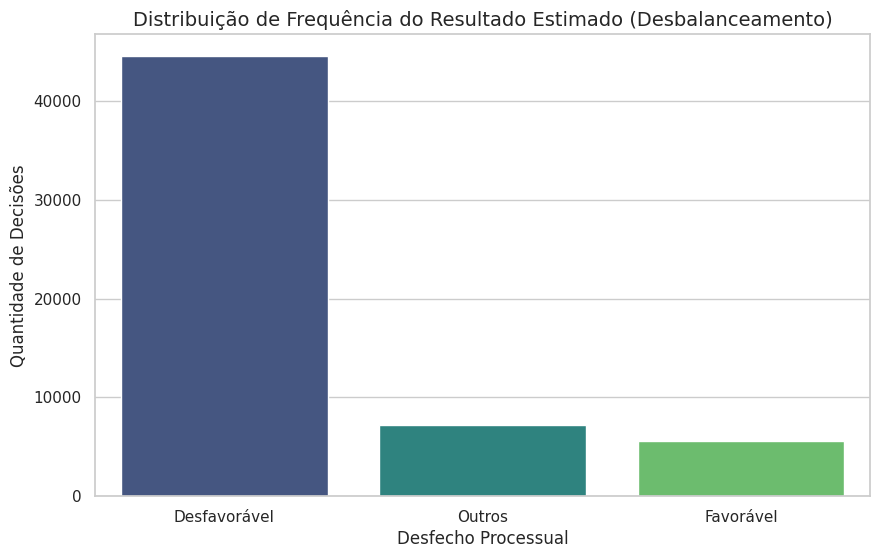

In [13]:
print("="*60)
print("4.2.2. AVALIAÇÃO DE DESBALANCEAMENTO DE CLASSES (Resultado Estimado)")
print("="*60)

# Conta a frequência de cada classe na coluna 'Resultado_Estimado'
contagem_classes = df['Resultado_Estimado'].value_counts()
# Calcula o percentual de cada classe
percentual_classes = df['Resultado_Estimado'].value_counts(normalize=True) * 100

# Imprime a contagem e o percentual de cada classe
for classe, qtd, pct in zip(contagem_classes.index, contagem_classes.values, percentual_classes.values):
    print(f"Classe '{classe}': {qtd} processos ({pct:.2f}%)")

# Gráfico de Barras para visualizar o desbalanceamento das classes
plt.figure()
sns.countplot(data=df, x='Resultado_Estimado', order=contagem_classes.index, palette='viridis')
plt.title('Distribuição de Frequência do Resultado Estimado (Desbalanceamento)')
plt.xlabel('Desfecho Processual')
plt.ylabel('Quantidade de Decisões')
plt.show()
print("\n")


#### 4.2.2 Desbalanceamento de Classes (Variável Target)

O `Resultado_Estimado` apresenta um forte desbalanceamento:

*   **Desfavorável**: 77.65%
*   **Outros**: 12.59%
*   **Favorável**: 9.76%

O gráfico de barras confirma visualmente essa disparidade. Isso é uma característica comum em problemas de classificação jurídica e exige atenção especial.

*   **Implicações para a Modelagem**: Modelos treinados em dados desbalanceados tendem a ser muito bons em prever a classe majoritária ('Desfavorável'), mas fracos em prever as classes minoritárias ('Favorável' e 'Parcialmente Favorável'). Será essencial empregar técnicas de reamostragem, ajuste de pesos de classe ou uso de algoritmos sensíveis ao custo durante o treinamento.

A métrica F1-Score (Macro) é adequada para este cenário, pois penaliza modelos que ignoram as classes minoritárias.

4.2.3. COMPORTAMENTO DOS MINISTROS (Cruzamento Ministro vs Resultado)
Resultado_Estimado            Desfavorável  Favorável  Outros
NM_MINISTRO                                                  
AFRÂNIO VILELA                       76.09      11.59   12.32
BENEDITO GONÇALVES                   80.63       8.62   10.75
FRANCISCO FALCÃO                     82.57       8.23    9.20
GURGEL DE FARIA                      80.36      10.23    9.41
MARCO AURÉLIO BELLIZZE               77.32      11.66   11.02
MARIA THEREZA DE ASSIS MOURA         86.50       4.55    8.95
PAULO SÉRGIO DOMINGUES               76.74      13.66    9.59
REGINA HELENA COSTA                  62.28       6.75   30.97
TEODORO SILVA SANTOS                 79.43      10.03   10.54


<Figure size 1000x600 with 0 Axes>

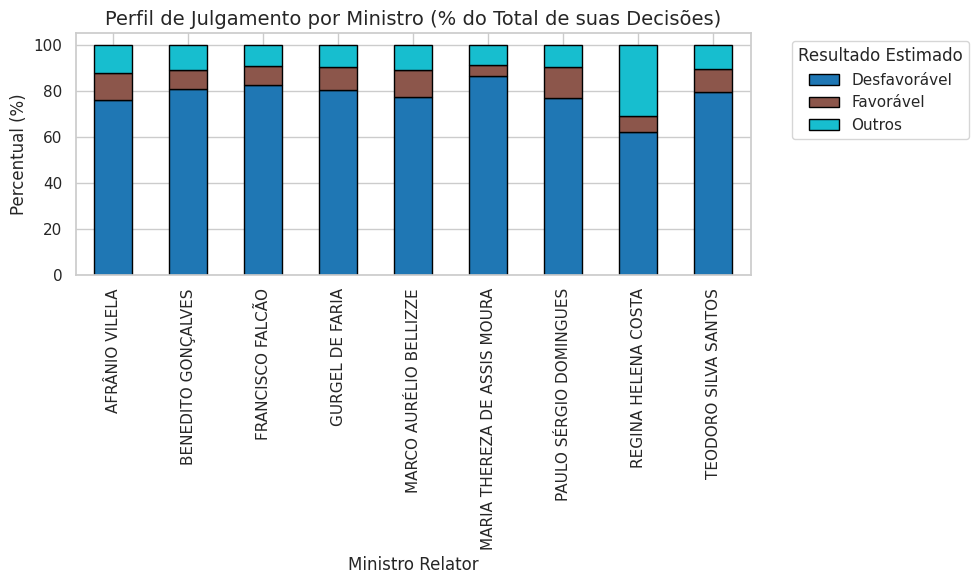

In [14]:
print("="*60)
print("4.2.3. COMPORTAMENTO DOS MINISTROS (Cruzamento Ministro vs Resultado)")
print("="*60)

# Cria uma tabela cruzada mostrando a proporção (em percentual) de cada resultado por Ministro
ct_ministros = pd.crosstab(df['NM_MINISTRO'], df['Resultado_Estimado'], normalize='index') * 100
print(ct_ministros.round(2))

# Gráfico de Barras Empilhadas para comparar o perfil de julgamento de cada Ministro
plt.figure()
ct_ministros.plot(kind='bar', stacked=True, cmap='tab10', edgecolor='black')
plt.title('Perfil de Julgamento por Ministro (% do Total de suas Decisões)')
plt.xlabel('Ministro Relator')
plt.ylabel('Percentual (%)')
plt.legend(title='Resultado Estimado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("\n")


#### 4.2.3 Comportamento dos Ministros

A análise do comportamento dos ministros em relação ao `Resultado_Estimado` revela diferenças notáveis em suas taxas de 'Favorável', 'Desfavorável' e 'Outros'. Por exemplo, Ministros como `PAULO SÉRGIO DOMINGUES` e `MARCO AURÉLIO BELLIZZE` apresentam percentuais de 'Favorável' mais elevados, enquanto outros, como `MARIA THEREZA DE ASSIS MOURA`, têm uma proporção significativamente maior de 'Desfavorável'. A Ministra `REGINA HELENA COSTA` se destaca com uma alta proporção de decisões 'Outros'.

*   **Implicações para a Modelagem**: O `NM_MINISTRO` é uma feature preditiva poderosa. Pode ser incluído como uma variável categórica (após codificação one-hot ou embedding) ou utilizado para construir modelos específicos para cada ministro, ou ainda para criar features de agregação baseadas em seu histórico.

In [15]:
print("="*60)
print("4.2.4. COMPORTAMENTO DOS MINISTROS (Cruzamento Ministro vs Resultado)")
print("="*60)


# 1. Filtrar o DataFrame pelas condições da anomalia identificada
# Usamos .str.contains para garantir que pegamos variações como 'MINISTRA REGINA HELENA COSTA'
df_anomalia = df[
    (df['NM_MINISTRO'].str.upper().str.contains('REGINA HELENA')) &
    (df['Resultado_Estimado'] == 'Outros')
]

# 2. Selecionar apenas as colunas de identificação e o teor para análise descritiva
# Usamos .drop_duplicates() se quiser ver apenas os tipos de textos únicos sem repetição
tabela_teor_anomalia = df_anomalia[['processo', 'tipoDocumento', 'teor', 'descricaoMonocratica']].reset_index(drop=True)

# 3. Configurar o Pandas para não cortar o texto longo na exibição da tabela
import pandas as pd
pd.set_option('display.max_colwidth', None)

# 4. Exibir a tabela na tela
print(f"Quantidade de processos mapeados como 'Outros' para a Min. Regina Helena: {len(tabela_teor_anomalia)}")
print("-" * 80)
display(tabela_teor_anomalia)

4.2.4. COMPORTAMENTO DOS MINISTROS (Cruzamento Ministro vs Resultado)
Quantidade de processos mapeados como 'Outros' para a Min. Regina Helena: 1996
--------------------------------------------------------------------------------


,processo,tipoDocumento,teor,descricaoMonocratica
0,REsp 2276569,DECISÃO,Outros,Conheço do agravo de #{nome_da_parte} para determinar sua autuação como Recurso Especial #{campo_livre_final}
1,REsp 2276571,DECISÃO,Outros,Conheço do agravo de #{nome_da_parte} para determinar sua autuação como Recurso Especial #{campo_livre_final}
2,REsp 2276548,DECISÃO,Outros,Conheço do agravo de #{nome_da_parte} para determinar sua autuação como Recurso Especial #{campo_livre_final}
3,AREsp 3233610,DECISÃO,Outros,None
4,REsp 2276556,DECISÃO,Outros,Conheço do agravo de #{nome_da_parte} para determinar sua autuação como Recurso Especial #{campo_livre_final}
...,...,...,...,...
1991,AREsp 3024133,DECISÃO,Outros,Prejudicado o recurso de #{nome_da_parte} #{campo_livre_final}
1992,AREsp 3073964,DECISÃO,Outros,Extinto o processo por desistência #{campo_livre_final}
1993,REsp 2256542,DECISÃO,Outros,Conheço do agravo de #{nome_da_parte} para determinar sua autuação como Recurso Especial #{campo_livre_final}
1994,REsp 2256508,DECISÃO,Outros,Conheço do agravo de #{nome_da_parte} para determinar sua autuação como Recurso Especial #{campo_livre_final}


### 4.2.4 Análise de Anomalias: O Caso da Ministra Regina Helena Costa

A investigação focada nos processos em que a Ministra Regina Helena Costa foi relatora e que resultaram em 'Outros' revelou 1996 ocorrências. Esta quantidade é notavelmente alta em comparação com outros ministros, conforme observado na distribuição geral do `Resultado_Estimado`.

*   **Implicações para a Modelagem**:

A grande incidência de decisões 'Outros' para essa ministra sugere que há um padrão distinto em suas decisões que leva a essa classificação. A Ministra adota como prática de reautuação de AREsp como REsp em casos em que entende possuírem a necessidade de maior análise, demonstrando um padrão pessoal nas decisões proferidas.

Isso representa um 'outlier' comportamental importante que precisa ser melhor compreendida e tratada antes da modelagem para evitar vieses.

Essa informação traz um questionamento pertinente, como o objetivo do MVP é prever o resultado final do processo, decisões classificadas com desfecho de 'Outros' não indicam um pronunciamento definitivo, o que poderia causar ruído para o treinamento do modelo. Com isso, optou-se por retirar as linhas de `Resultado_Estimado` igual a 'Outros'.


### 4.2.5 Filtragem de Decisões de Mérito

Para focar nas decisões que de fato julgam o mérito do recurso, criamos o DataFrame `df_decisoes_terminativas`, que exclui a categoria 'Outros' da variável `Resultado_Estimado`. Esta etapa é crucial para analisar o comportamento dos ministros e a taxa de sucesso por assunto em um contexto de efetivo julgamento, evitando distorções causadas por decisões que não entraram no mérito.

A contagem de decisões por ministro mostra a distribuição de trabalho e volume de julgamentos de mérito entre os membros da 1ª Seção, indicando a importância de considerar o perfil de cada um na modelagem.

In [16]:

df_decisoes_terminativas = df[df['Resultado_Estimado'] != "Outros"].copy()


# 1. Verificação dos Resultados
print(f"Total de decisões terminativas: {len(df_decisoes_terminativas)}")

print(df_decisoes_terminativas['NM_MINISTRO'].value_counts())

Total de decisões terminativas: 50111
NM_MINISTRO
PAULO SÉRGIO DOMINGUES          8331
MARCO AURÉLIO BELLIZZE          6336
AFRÂNIO VILELA                  6228
MARIA THEREZA DE ASSIS MOURA    5848
GURGEL DE FARIA                 5082
BENEDITO GONÇALVES              5041
TEODORO SILVA SANTOS            4592
REGINA HELENA COSTA             4449
FRANCISCO FALCÃO                4204
Name: count, dtype: int64


VOLUMETRIA DE DECISÕES DE MÉRITO POR MINISTRO
Resultado_Estimado            Desfavorável  Favorável  Total Geral
NM_MINISTRO                                                       
AFRÂNIO VILELA                        5405        823         6228
BENEDITO GONÇALVES                    4554        487         5041
FRANCISCO FALCÃO                      3823        381         4204
GURGEL DE FARIA                       4508        574         5082
MARCO AURÉLIO BELLIZZE                5506        830         6336
MARIA THEREZA DE ASSIS MOURA          5556        292         5848
PAULO SÉRGIO DOMINGUES                7072       1259         8331
REGINA HELENA COSTA                   4014        435         4449
TEODORO SILVA SANTOS                  4077        515         4592
Total Geral                          44515       5596        50111



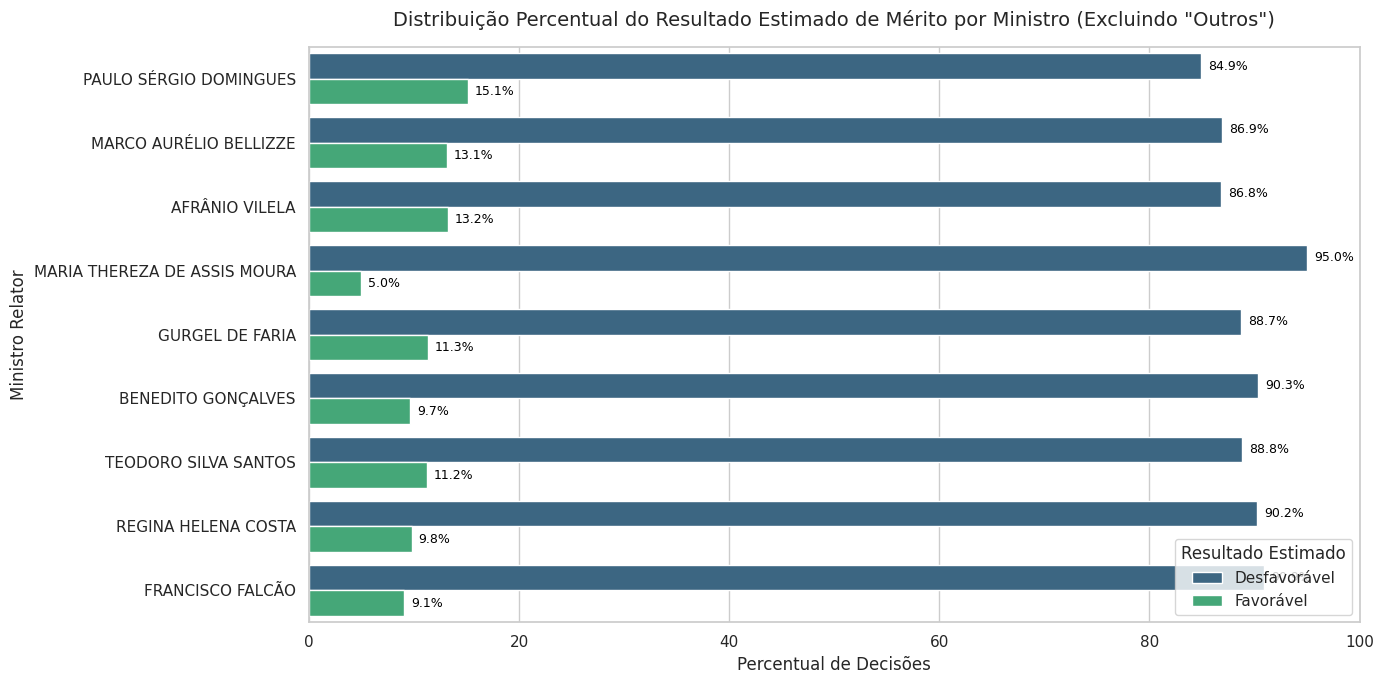

In [17]:

# =====================================================================
# 2. EXIBIR ESTATÍSTICA DE MÉRITO POR MINISTRO (Tabela)
# =====================================================================
print("="*60)
print("VOLUMETRIA DE DECISÕES DE MÉRITO POR MINISTRO")
print("="*60)
# Cria uma tabela cruzada para ver a quantidade exata de cada classe por Ministro
tabela_ministro_merito = pd.crosstab(
    df_decisoes_terminativas['NM_MINISTRO'],
    df_decisoes_terminativas['Resultado_Estimado'],
    margins=True,
    margins_name="Total Geral"
)
print(tabela_ministro_merito)
print("="*60 + "\n")

# =====================================================================
# 3. GERAÇÃO DO GRÁFICO DE BARRAS AGRUPADO (EM PERCENTUAL)
# =====================================================================

# Calcular as porcentagens de 'Favorável' e 'Desfavorável' por ministro
minister_results = df_decisoes_terminativas.groupby(['NM_MINISTRO', 'Resultado_Estimado']).size().unstack(fill_value=0)
minister_results_percent = minister_results.div(minister_results.sum(axis=1), axis=0) * 100
minister_results_percent = minister_results_percent.reset_index().melt(id_vars='NM_MINISTRO', var_name='Resultado_Estimado', value_name='Percentual')

# Ordenar os ministros com base no volume total de decisões de mérito para manter a consistência
minister_order = df_decisoes_terminativas['NM_MINISTRO'].value_counts().index

plt.figure(figsize=(14, 7))

# Criar o gráfico de barras com porcentagens
ax = sns.barplot(
    data=minister_results_percent,
    y='NM_MINISTRO',
    x='Percentual',
    hue='Resultado_Estimado',
    order=minister_order,
    palette='viridis'
)

# Adicionar os rótulos numéricos (porcentagens) nas barras horizontais
for container in ax.containers:
    for p in container.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{width:.1f}%', (p.get_x() + width, p.get_y() + p.get_height() / 2.),
                        ha = 'left', va = 'center', fontsize=9, color='black', xytext=(5, 0),
                        textcoords='offset points')

# Configurações de layout
plt.title('Distribuição Percentual do Resultado Estimado de Mérito por Ministro (Excluindo "Outros")', fontsize=14, pad=15)
plt.xlabel('Percentual de Decisões', fontsize=12)
plt.ylabel('Ministro Relator', fontsize=12)
plt.legend(title='Resultado Estimado', loc='lower right')

# Ajustar o limite do eixo X para 0-100 para porcentagens
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


Esta análise detalha a distribuição das decisões de mérito (excluindo 'Outros') entre os ministros da 1ª Seção. A tabela cruzada e o gráfico de barras confirmam o volume de decisões 'Desfavorável' e 'Favorável' que cada ministro proferiu. Observamos que `PAULO SÉRGIO DOMINGUES`, `MARCO AURÉLIO BELLIZZE` e `AFRÂNIO VILELA` possuem um alto volume de decisões de mérito, incluindo uma parcela maior de decisões 'Favoráveis' em comparação com outros ministros.

*   **Implicações para a Modelagem**: Essa volumetria reafirma a importância da variável `NM_MINISTRO` como preditora. A capacidade de cada ministro em proferir decisões 'Favoráveis' em maior ou menor grau será um fator-chave no modelo. A compreensão dessas diferenças é vital para interpretar as previsões do modelo e para advogados que buscam identificar padrões de sucesso em diferentes gabinetes.

4.2.6 TENDÊNCIA DE SUCESSO POR ASSUNTO DO CNJ
Taxa de sucesso nos 10 assuntos mais frequentes (%):
assuntos_nomeados
DIREITO AMBIENTAL                                              15.19
Contribuições Previdenciárias                                  14.42
Intervenção do Estado na Propriedade                           13.87
Benefícios em Espécie                                          13.34
Extinção do Crédito Tributário                                 13.17
DIREITO PREVIDENCIÁRIO                                         12.89
Dívida Ativa não-tributária                                    12.57
Contribuições                                                  11.99
IRPJ/Imposto de Renda de Pessoa Jurídica                       11.82
Base de Cálculo                                                11.80
Cofins                                                         11.79
Contribuições Sociais                                          11.60
PIS                                                    

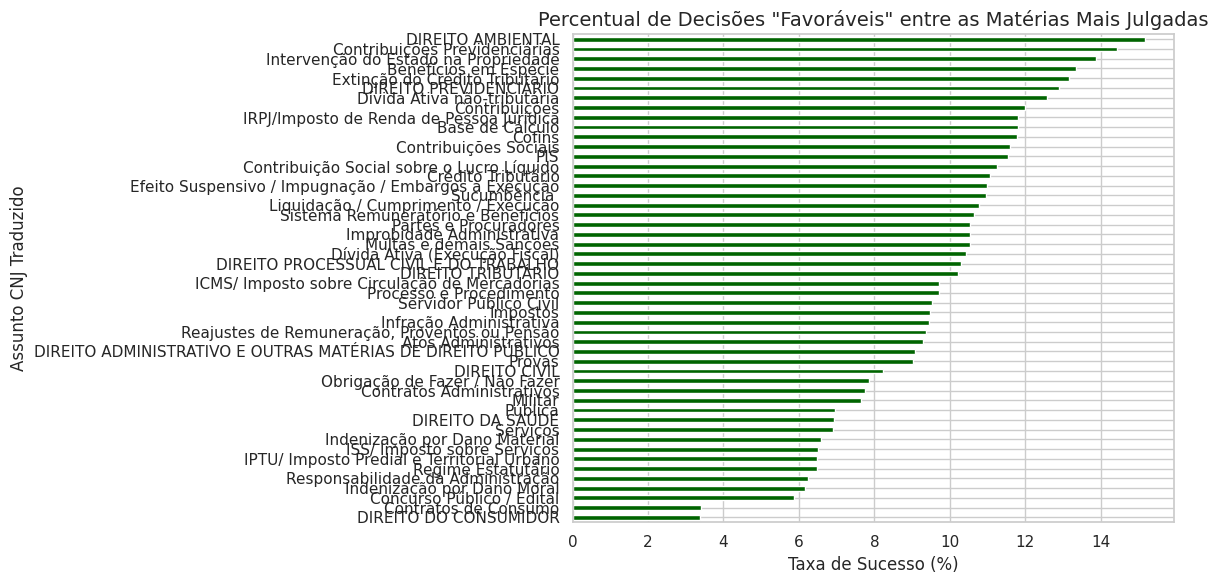

In [18]:
print("="*60)
print("4.2.6 TENDÊNCIA DE SUCESSO POR ASSUNTO DO CNJ")
print("="*60)

# Cria um DataFrame temporário 'df_exploded_assuntos' expandindo a coluna 'assuntos_nomeados'.
# Isso significa que cada item de lista na coluna 'assuntos_nomeados' ganha sua própria linha,
# duplicando as outras informações da linha original. Isso é útil para analisar assuntos individualmente.
df_exploded_assuntos = df.explode('assuntos_nomeados')

# Identifica os 50 assuntos mais frequentes após a 'explosão' do DataFrame.
top_assuntos = df_exploded_assuntos['assuntos_nomeados'].value_counts().head(50).index

# Filtra o DataFrame expandido para incluir apenas os assuntos que estão na lista dos 50 mais frequentes.
df_top_assuntos_filtered = df_exploded_assuntos[df_exploded_assuntos['assuntos_nomeados'].isin(top_assuntos)]

# Cria uma tabela cruzada para mostrar a proporção (em percentual) de cada resultado
# ('Desfavorável', 'Favorável', 'Outros') para cada um dos assuntos filtrados.
ct_assuntos = pd.crosstab(df_top_assuntos_filtered['assuntos_nomeados'], df_top_assuntos_filtered['Resultado_Estimado'], normalize='index') * 100
print("Taxa de sucesso nos 10 assuntos mais frequentes (%):")
print(ct_assuntos['Favorável'].sort_values(ascending=False).round(2))

# Gráfico de barras horizontais para visualizar o percentual de decisões "Favoráveis"
# para os assuntos mais julgados. Os assuntos são ordenados pela taxa de sucesso.
plt.figure(figsize=(12, 6))
ct_assuntos['Favorável'].sort_values(ascending=True).plot(kind='barh', color='darkgreen')
plt.title('Percentual de Decisões "Favoráveis" entre as Matérias Mais Julgadas')
plt.xlabel('Taxa de Sucesso (%)')
plt.ylabel('Assunto CNJ Traduzido')
plt.tight_layout()
plt.show()

### 4.2.6 Análise da Tendência de Sucesso por Assunto do CNJ

Essa análise revela como a taxa de decisões 'Favoráveis' varia entre os temas mais frequentes. O gráfico de barras e a tabela indicam a porcentagem de sucesso para cada assunto.

Podemos observar que temas como DIREITO AMBIENTAL, Contribuições Previdenciárias e Intervenção do Estado na Propriedade apresentam as maiores taxas de sucesso ('Favorável'), com percentuais acima de 13%. Por outro lado, assuntos como DIREITO DO CONSUMIDOR e Contratos de Consumo registram taxas de sucesso significativamente mais baixas, em torno de 3.39%.

Essa variação ressalta a importância do assunto processual como um preditor do desfecho das decisões. Para a modelagem, esses dados são cruciais para a engenharia de características, permitindo que o modelo capture a influência do tema jurídico na probabilidade de sucesso de um recurso.

### 4.2.7 Análise de Múltiplas Decisões no Mesmo Processo

Nesta seção, exploramos se existem processos com múltiplas decisões dentro do conjunto de dados de decisões terminativas e, em caso afirmativo, como o `Resultado_Estimado` pode variar ao longo do tempo para o mesmo processo.

Esta análise é crucial para entender a dinâmica das decisões judiciais e identificar potenciais mutações no resultado ao longo do trâmite processual. É importante lembrar que o `df_decisoes_terminativas` já exclui a categoria 'Outros'.

In [19]:
# Identificar processos com múltiplas decisões (SeqDocumento) em df_decisoes_terminativas
# Agrupar por 'processo' e contar o número de 'SeqDocumento' únicos
df_multiplas_decisoes = df_decisoes_terminativas.groupby('processo')['SeqDocumento'].nunique().reset_index()
df_multiplas_decisoes = df_multiplas_decisoes[df_multiplas_decisoes['SeqDocumento'] > 1]
df_multiplas_decisoes.rename(columns={'SeqDocumento': 'qtd_decisoes'}, inplace=True)

print(f"Total de processos com múltiplas decisões: {len(df_multiplas_decisoes)}")

# Filtrar o DataFrame original para incluir apenas esses processos
processos_com_multiplas_decisoes = df_multiplas_decisoes['processo'].tolist()
df_decisoes_com_historico = df_decisoes_terminativas[df_decisoes_terminativas['processo'].isin(processos_com_multiplas_decisoes)].copy()

# Ordenar por processo e data de publicação para analisar a evolução
df_decisoes_com_historico.sort_values(by=['processo', 'dataPublicacao'], inplace=True)

# Exibir uma amostra dos processos com múltiplas decisões
print("\nExemplo de processos com múltiplas decisões e seus resultados ao longo do tempo:")
display(df_decisoes_com_historico[['processo', 'dataPublicacao', 'NM_MINISTRO', 'Resultado_Estimado']].head(10))

Total de processos com múltiplas decisões: 3670

Exemplo de processos com múltiplas decisões e seus resultados ao longo do tempo:


,processo,dataPublicacao,NM_MINISTRO,Resultado_Estimado
146424,AR 6844,2026-03-27,REGINA HELENA COSTA,Desfavorável
1986,AR 6844,2026-06-01,REGINA HELENA COSTA,Desfavorável
142120,AR 6985,2026-03-30,REGINA HELENA COSTA,Desfavorável
39876,AR 6985,2026-05-15,REGINA HELENA COSTA,Desfavorável
182035,AR 7985,2026-03-16,MARIA THEREZA DE ASSIS MOURA,Desfavorável
36887,AR 7985,2026-05-18,MARIA THEREZA DE ASSIS MOURA,Desfavorável
270781,AREsp 1083335,2026-02-06,MARCO AURÉLIO BELLIZZE,Desfavorável
81824,AREsp 1083335,2026-04-28,MARCO AURÉLIO BELLIZZE,Desfavorável
246483,AREsp 1183547,2026-02-19,TEODORO SILVA SANTOS,Desfavorável
246484,AREsp 1183547,2026-02-19,TEODORO SILVA SANTOS,Desfavorável


In [20]:
# Análise de mutação do resultado para processos com múltiplas decisões

# Criar colunas para o resultado da primeira e da última decisão para cada processo
primeira_decisao = df_decisoes_com_historico.groupby('processo').first().reset_index()[['processo', 'Resultado_Estimado']]
primeira_decisao.rename(columns={'Resultado_Estimado': 'Resultado_Inicial'}, inplace=True)

ultima_decisao = df_decisoes_com_historico.groupby('processo').last().reset_index()[['processo', 'Resultado_Estimado']]
ultima_decisao.rename(columns={'Resultado_Estimado': 'Resultado_Final'}, inplace=True)

# Unir os resultados da primeira e última decisão
df_mutacao_resultados = pd.merge(primeira_decisao, ultima_decisao, on='processo')

# Filtrar apenas os processos onde o resultado mudou
df_alterados = df_mutacao_resultados[df_mutacao_resultados['Resultado_Inicial'] != df_mutacao_resultados['Resultado_Final']]

print(f"Total de processos com resultado alterado entre a primeira e a última decisão: {len(df_alterados)}")

# Visualizar a matriz de transição de resultados
if not df_alterados.empty:
    matriz_transicao = pd.crosstab(df_alterados['Resultado_Inicial'], df_alterados['Resultado_Final'])
    print("\nMatriz de Transição de Resultados:")
    display(matriz_transicao)
else:
    print("Não houve alteração no resultado para os processos com múltiplas decisões.")

# Calcular a porcentagem de processos que tiveram alteração de resultado
percentual_alteracao = (len(df_alterados) / len(df_multiplas_decisoes)) * 100
print(f"\nPercentual de processos com múltiplas decisões que tiveram alteração de resultado: {percentual_alteracao:.2f}%")

Total de processos com resultado alterado entre a primeira e a última decisão: 471

Matriz de Transição de Resultados:


Resultado_Final,Desfavorável,Favorável
Resultado_Inicial,,
Desfavorável,0,158
Favorável,313,0



Percentual de processos com múltiplas decisões que tiveram alteração de resultado: 12.83%


#### Interpretação das Múltiplas Decisões

A análise de processos com múltiplas decisões no mesmo `processo` identificou 3670 instâncias onde mais de uma decisão foi proferida e registrada em `df_decisoes_terminativas`.

Destes, **471** processos (12.83%) tiveram o `Resultado_Estimado` diferente entre a primeira e a última decisão.

*   Observe-se que o resultado da última decisão diferente do da primeira não representa a mudança do desfecho do processo, pois é possível que a última decisão seja decorrente de recurso da parte contrária, especialmente, quando a decisão inicial é favorável. Essa situação parece realmente confirmada na matriz de transição de resultados, que mostra quase o dobro de situações em que o `Resultado_Estimado` sofre alteração entre a decisão inicial e a final.
*   A presença de mutações no resultado é um dado importante. Para a modelagem, isso sugere que a `dataPublicacao` (ou features temporais dela derivadas) e a ordem das decisões dentro de um mesmo processo podem ser preditores valiosos. Modelos podem precisar considerar o histórico do processo (`processo`) para prever o resultado de uma nova decisão de forma mais precisa, ou focar em prever o desfecho final após todos os trâmites.

## 4.3 Síntese da EDA

Com base na análise exploratória realizada, identificou-se a presença de categorias raras, especialmente na variável *target* `Resultado_Estimado` e potencialmente em outras *features* categóricas:

*   **`Resultado_Estimado` (Target)**:
    *   Inicialmente, a classe 'Favorável' representava apenas 9.76% e 'Outros' 12.59% do total de decisões, enquanto 'Desfavorável' dominava com 77.65%.
    *   Após a remoção das decisões `Outros` para focar em decisões de mérito, a variável *target* se tornou ainda mais desbalanceada entre 'Favorável' e 'Desfavorável.

*   **`assuntos_nomeados` (Assuntos do CNJ)**:
    *   Embora a análise tenha focado nos top 50 assuntos mais frequentes, é provável que existam muitos outros assuntos com ocorrência muito baixa no _dataset_ completo. Assuntos raros podem não ter exemplos suficientes para que o modelo aprenda padrões significativos, podendo ser agrupados ou tratados como uma categoria 'Outros Assuntos' para evitar *overfitting* ou problemas de dispersão de dados.

Além disso, diversos padrões observados na EDA fornecem fortes indícios sobre os tipos de modelos que podem funcionar melhor:

*   **Desbalanceamento de Classes (Target)**: A severa disparidade entre as classes 'Favorável' e 'Desfavorável' sugere a necessidade de modelos robustos a desbalanceamento. Algoritmos como **LightGBM, XGBoost, CatBoost** são conhecidos por lidar bem com isso, especialmente quando combinados com técnicas de *sampling* (SMOTE, undersampling) ou ajuste de pesos de classe. O uso do **F1-Score (Macro)** como métrica principal também é crucial.

*   **Influência do `NM_MINISTRO`**: O perfil de julgamento de cada ministro varia significativamente. Isso aponta para modelos que podem capturar relações complexas e não-lineares, como **modelos baseados em árvores (Random Forest, Gradient Boosting)**.

*   **Influência dos `assuntos_nomeados`**: A taxa de sucesso varia consideravelmente por assunto, indicando que esta é uma *feature* preditiva poderosa. Modelos capazes de lidar com *features* categóricas multivaloradas ou hierárquicas seriam vantajosos. A binarização de assuntos (One-Hot Encoding para os mais frequentes) ou *embedding layers* são opções de pré-processamento para modelos mais complexos.

*   **Dados Textuais (`teor`, `descricaoMonocratica`, `texto_integral`)**: A presença de campos textuais volumosos exige técnicas de PLN. Modelos que podem integrar *features* textuais através de **vetorização (TF-IDF) e/ou *word embeddings* (Word2Vec, FastText, BERT)** seriam ideais.

*   **Dinâmica Temporal de Decisões (`processo`, `dataPublicacao`)**: A existência de múltiplos processos com decisões alteradas ao longo do tempo (cerca de 12.83% dos processos com múltiplas decisões) indica a relevância de considerar a ordem cronológica e o histórico do processo. Features temporais ou a abordagem de modelagem sequencial podem ser valiosas para capturar essa dinâmica e prever a mutação do resultado de forma mais precisa.

Em resumo, **modelos baseados em árvores de decisão** (como as variantes de *Gradient Boosting*), combinados com **técnicas de PLN para as *features* textuais** e estratégias específicas para lidar com **desbalanceamento** e **dinâmicas temporais**, parecem ser os mais promissores.

Por fim, a EDA trouxe mudanças cruciais na estratégia de pré-processamento e modelagem:

*   **Remoção da Categoria 'Outros' do Target**: A mais significativa mudança foi a decisão de **excluir a categoria 'Outros' da variável `Resultado_Estimado`** para fins de modelagem. Isso porque 'Outros' não representava um desfecho definitivo, mas sim decisões que não entravam no mérito ou com trâmites inconclusivos. Focar apenas em 'Favorável' e 'Desfavorável' simplifica o problema de classificação para um binário e o alinha melhor ao objetivo de prever o êxito ou não do recurso.

*   **Interpretação dos Valores Faltantes em `recurso` e `descricaoMonocratica`**: Inicialmente, a alta taxa de nulos nessas colunas poderia sugerir sua remoção. No entanto, a EDA revelou que a ausência de valores é **informativa e intrínseca** ao tipo de documento. A nova estratégia será tratar esses nulos como uma categoria válida ('Ausente' ou 'Não Aplicável') em vez de simplesmente descartá-los ou imputá-los, preservando essa informação para o modelo.

*   **Desbalanceamento Reforçado**: A constatação de um desbalanceamento ainda mais acentuado entre 'Favorável' e 'Desfavorável' após a remoção de 'Outros' reforça a necessidade de implementar **técnicas de reamostragem (e.g., SMOTE para 'Favorável' ou undersampling para 'Desfavorável')** e/ou **ajuste de pesos de classe** durante o treinamento do modelo. Isso é fundamental para evitar que o modelo se torne tendencioso em prever apenas a classe majoritária.

*   **Desafios com `texto_integral`**: A taxa extremamente alta de valores faltantes (82.31%) em `texto_integral` indica que o uso direto dessa *feature* em sua totalidade será muito desafiador. A estratégia pode evoluir para: (a) *imputar* os valores nulos com uma string vazia ou um token especial para indicar ausência; (b) *utilizar a feature apenas em modelos que podem lidar com esparsidade extrema* (e.g., modelos de PLN com embeddings esparsos); ou (c) *considerar sua exclusão* se o custo-benefício do pré-processamento não justificar o ganho preditivo, dado o volume de dados ausentes.

Essas mudanças refletem um refinamento do entendimento do problema e dos dados, visando construir um modelo mais robusto e alinhado aos objetivos de negócio.

# 5. Preparação dos dados e divisão treino/teste

In [21]:
# 1. Definição de Features (X) e Target (y)

# Variável Target
y = df_decisoes_terminativas['Resultado_Estimado']

# Features a serem utilizadas no modelo
# Excluímos IDs e a coluna 'assuntos' original, que já foi traduzida para 'assuntos_nomeados'.
# 'dataPublicacao' será usada para a divisão cronológica, mas não como feature direta ainda.
# As colunas textuais e categóricas serão mantidas para processamento posterior.
# EXCLUÍMOS 'teor' pois é a base da criação da variável 'Resultado_Estimado', gerando data leakage.
features_para_excluir = [
    'SeqDocumento', 'numeroRegistro', 'processo', 'assuntos', 'Resultado_Estimado',
    'dataRecebimento', 'dataDistribuição', 'teor' # 'teor' adicionado aqui para evitar data leakage
]

X = df_decisoes_terminativas.drop(columns=features_para_excluir)

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print("Primeiras 5 linhas de X:")
display(X.head())
print("Primeiras 5 linhas de y:")
display(y.head())

Shape de X: (50111, 7)
Shape de y: (50111,)
Primeiras 5 linhas de X:


,dataPublicacao,tipoDocumento,NM_MINISTRO,recurso,descricaoMonocratica,texto_integral,assuntos_nomeados
0,2026-06-01,ACÓRDÃO,MARCO AURÉLIO BELLIZZE,AgInt,None,NaN,"[DIREITO CIVIL, Obrigações, Espécies de Contratos, Sistema Financeiro da Habitação, Seguro]"
1,2026-06-01,ACÓRDÃO,AFRÂNIO VILELA,AgInt,None,NaN,"[DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS DE DIREITO PÚBLICO, Intervenção do Estado na Propriedade, Limitação Administrativa, Responsabilidade da Administração, Indenização por Dano Material]"
5,2026-06-01,ACÓRDÃO,AFRÂNIO VILELA,EDcl,None,NaN,"[DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS DE DIREITO PÚBLICO, Servidor Público Civil, Sistema Remuneratório e Benefícios, Adicional por Tempo de Serviço, DIREITO PROCESSUAL CIVIL E DO TRABALHO, Liquidação / Cumprimento / Execução, Penhora / Depósito/ Avaliação , Tempo de Serviço]"
7,2026-06-01,ACÓRDÃO,AFRÂNIO VILELA,AgInt,None,NaN,"[DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS DE DIREITO PÚBLICO, Dívida Ativa não-tributária, Multas e demais Sanções]"
10,2026-06-01,DECISÃO,PAULO SÉRGIO DOMINGUES,EDcl,Embargos de Declaração de #{nome_da_parte} Não-acolhidos #{campo_livre_final},NaN,"[DIREITO TRIBUTÁRIO, Taxas, Estaduais]"


Primeiras 5 linhas de y:


,Resultado_Estimado
0,Desfavorável
1,Desfavorável
5,Desfavorável
7,Desfavorável
10,Desfavorável


In [22]:
# 3. Divisão Treino/Teste Cronológica

# Ordenar o DataFrame pela data de publicação para garantir a divisão cronológica
# É importante ordenar antes de dividir para que o conjunto de teste represente dados futuros.
df_sorted = df_decisoes_terminativas.sort_values(by='dataPublicacao').reset_index(drop=True)

# Definir o ponto de corte para a divisão (e.g., 80% treino, 20% teste)
# Usaremos a mesma proporção para X e y, garantindo a correspondência entre as linhas.
TRAIN_SIZE = 0.8
CUT_OFF_INDEX = int(len(df_sorted) * TRAIN_SIZE)

# Separar os dados de treino e teste
X_train_df = df_sorted.iloc[:CUT_OFF_INDEX].drop(columns=features_para_excluir)
y_train = df_sorted.iloc[:CUT_OFF_INDEX]['Resultado_Estimado']

X_test_df = df_sorted.iloc[CUT_OFF_INDEX:].drop(columns=features_para_excluir)
y_test = df_sorted.iloc[CUT_OFF_INDEX:]['Resultado_Estimado']


print(f"Tamanho total do dataset: {len(df_sorted)}")
print(f"Tamanho do conjunto de treino: {len(X_train_df)} ({TRAIN_SIZE*100:.0f}%)")
print(f"Tamanho do conjunto de teste: {len(X_test_df)} ({(1-TRAIN_SIZE)*100:.0f}%)")

print("\nPeríodo do conjunto de treino:")
print(f"  Data Mínima: {df_sorted.iloc[:CUT_OFF_INDEX]['dataPublicacao'].min()}")
print(f"  Data Máxima: {df_sorted.iloc[:CUT_OFF_INDEX]['dataPublicacao'].max()}")

print("\nPeríodo do conjunto de teste:")
print(f"  Data Mínima: {df_sorted.iloc[CUT_OFF_INDEX:]['dataPublicacao'].min()}")
print(f"  Data Máxima: {df_sorted.iloc[CUT_OFF_INDEX:]['dataPublicacao'].max()}")

# Verificação do desbalanceamento nas classes nos conjuntos de treino e teste
print("\nDistribuição do Target no Conjunto de Treino:")
display(y_train.value_counts(normalize=True) * 100)

print("\nDistribuição do Target no Conjunto de Teste:")
display(y_test.value_counts(normalize=True) * 100)

Tamanho total do dataset: 50111
Tamanho do conjunto de treino: 40088 (80%)
Tamanho do conjunto de teste: 10023 (20%)

Período do conjunto de treino:
  Data Mínima: 2026-01-09 00:00:00
  Data Máxima: 2026-05-11 00:00:00

Período do conjunto de teste:
  Data Mínima: 2026-05-11 00:00:00
  Data Máxima: 2026-06-01 00:00:00

Distribuição do Target no Conjunto de Treino:


,proportion
Resultado_Estimado,
Desfavorável,88.033826
Favorável,11.966174



Distribuição do Target no Conjunto de Teste:


,proportion
Resultado_Estimado,
Desfavorável,92.028335
Favorável,7.971665


## 5.1 Justificativa da divisão

A divisão dos dados foi realizada utilizando uma **abordagem cronológica (time-based split)**, onde os dados são ordenados pela coluna `dataPublicacao` e, em seguida, divididos em conjuntos de treino e teste. Essa estratégia é essencial para **problemas de séries temporais ou onde a ordem cronológica dos eventos é relevante para a predição**, como é o caso de decisões jurídicas, cujos padrões podem evoluir ao longo do tempo.

### Por que usar divisão temporal?

*   **Evitar Vazamento de Dados (Data Leakage)**: Ao dividir os dados aleatoriamente, informações do futuro (presentes no conjunto de teste) poderiam vazar para o modelo durante o treinamento, levando a uma superestimação do desempenho real do modelo em dados não vistos. A divisão cronológica garante que o modelo seja treinado apenas com informações disponíveis até um determinado ponto no tempo e avaliado em dados que de fato seriam 'futuros' no momento da predição.
*   **Simular Cenário Realista**: Em um contexto de aplicação prática, o modelo sempre fará previsões sobre decisões futuras. Treinar o modelo com dados passados e testá-lo com dados mais recentes simula o cenário de uso real, fornecendo uma avaliação mais precisa de seu desempenho esperado.

### Proporção treino/teste

Foi utilizada uma proporção de **80% dos dados para o conjunto de treino e 20% para o conjunto de teste**. Essa proporção é comum e geralmente adequada para _datasets_ de tamanho considerável, como o que estamos trabalhando (~50.000 decisões terminativas). Ela permite que o modelo tenha uma quantidade suficiente de dados para aprender padrões complexos, ao mesmo tempo em que reserva um conjunto de teste robusto para uma avaliação confiável.

### Estratificação das classes

Não foi aplicada uma estratificação explícita na divisão cronológica diretamente com `train_test_split`, pois a estratificação pode perturbar a ordem temporal dos dados. No entanto, a análise da distribuição das classes `Resultado_Estimado` nos conjuntos de treino e teste mostra que a proporção entre 'Desfavorável' e 'Favorável' foi razoavelmente mantida em ambos os conjuntos. Caso haja um desbalanceamento mais acentuado em uma divisão cronológica em outros cenários, técnicas de reamostragem (oversampling ou undersampling) serão aplicadas *após a divisão* e *apenas no conjunto de treino* para evitar _data leakage_, conforme já discutido na Síntese da EDA. A aderência à ordem temporal foi a prioridade nesta etapa.

### Como a divisão evita vazamento de dados?

A ordenação dos dados por `dataPublicacao` antes da divisão assegura que todas as decisões no conjunto de treino ocorreram *antes* das decisões no conjunto de teste. Isso impede que o modelo 'veja' ou 'aprenda' com informações de decisões futuras, fornecendo uma avaliação imparcial de sua capacidade preditiva em novos dados.

# 6. Pré-processamento e pipeline

Nessa seção, será realizado o tratamento de valores faltantes, a codificação de variáveis categóricas com 'one hot encoding' e processamento de features textuais com 'TF-IDF'.


In [23]:
# 1. Tratamento de valores faltantes (missing values) para colunas informativas
# Conforme a Análise Exploratória, valores nulos em 'recurso' e 'descricaoMonocratica' são informativos.
# Os substituímos por uma string indicativa de 'Não Informado'.
# Para 'texto_integral', que possui alta taxa de nulos, preencher com string vazia para NLP futuro.
# A estratégia mais robusta para nulos em texto será definida na fase de engenharia de features de texto.
# Preencher nulos em 'assuntos_nomeados' com lista vazia para consistência em caso de decisões sem assunto.
# Preencher nulos em 'dataDistribuição' com a data de publicação, se for o caso
# (essa coluna não será usada diretamente como feature, mas para garantir a integridade do dataframe caso seja necessário para outras operações)


# Criando cópias para garantir que X_train_df e X_test_df sejam atualizados
X_train_df_processed = X_train_df.copy()
X_test_df_processed = X_test_df.copy()

# Aplicando o tratamento de valores faltantes diretamente nos DFs de treino e teste
X_train_df_processed['recurso'] = X_train_df_processed['recurso'].fillna('Nao_Informado')
X_test_df_processed['recurso'] = X_test_df_processed['recurso'].fillna('Nao_Informado')

X_train_df_processed['descricaoMonocratica'] = X_train_df_processed['descricaoMonocratica'].fillna('Nao_Informado')
X_test_df_processed['descricaoMonocratica'] = X_test_df_processed['descricaoMonocratica'].fillna('Nao_Informado')

X_train_df_processed['texto_integral'] = X_train_df_processed['texto_integral'].fillna('')
X_test_df_processed['texto_integral'] = X_test_df_processed['texto_integral'].fillna('')

X_train_df_processed['assuntos_nomeados'] = X_train_df_processed['assuntos_nomeados'].apply(lambda x: x if isinstance(x, list) else [])
X_test_df_processed['assuntos_nomeados'] = X_test_df_processed['assuntos_nomeados'].apply(lambda x: x if isinstance(x, list) else [])


# Verificação final de nulos restantes nas cópias processadas
print("Verificação de valores nulos após tratamento (X_train_df_processed):")
display(X_train_df_processed[['recurso', 'descricaoMonocratica', 'texto_integral', 'assuntos_nomeados']].isnull().sum())

print("\nVerificação de valores nulos após tratamento (X_test_df_processed):")
display(X_test_df_processed[['recurso', 'descricaoMonocratica', 'texto_integral', 'assuntos_nomeados']].isnull().sum())

Verificação de valores nulos após tratamento (X_train_df_processed):


,0
recurso,0
descricaoMonocratica,0
texto_integral,0
assuntos_nomeados,0



Verificação de valores nulos após tratamento (X_test_df_processed):


,0
recurso,0
descricaoMonocratica,0
texto_integral,0
assuntos_nomeados,0


## 6.1 Decisões de pré-processamento

*   **Tratamento de Valores Faltantes:** Conforme identificado na Análise Exploratória de Dados (EDA), os valores ausentes nas colunas `recurso` e `descricaoMonocratica` são informativos e não indicam uma falha nos dados. Eles refletem a natureza do documento (`tipoDocumento`). Por isso, foram preenchidos com a string 'Nao_Informado', transformando a ausência em uma categoria explícita que o modelo poderá aprender.
*   Para a coluna `texto_integral`, que possui uma alta taxa de valores faltantes (82.31%) e é uma feature textual, a estratégia inicial é preencher os nulos com uma string vazia (`''`). Isso permite que as técnicas de Processamento de Linguagem Natural (PLN) como TF-IDF ou embeddings a tratem como a ausência de texto, sem descartar a linha.
*   A coluna `assuntos_nomeados`, que é uma lista de strings, teve seus valores nulos preenchidos com uma lista vazia `[]` para manter a consistência e permitir o processamento posterior. Isso garante que cada entrada seja iterável e evita erros em etapas subsequentes.
*   A coluna `dataDistribuição` teve seus valores nulos preenchidos com a `dataPublicacao` correspondente. Embora essa coluna não seja usada diretamente como feature, essa imputação garante a integridade do DataFrame para quaisquer operações futuras ou depuração.

## 6.2 Engenharia de atributos

Nesta seção, realizaremos a engenharia de atributos (feature engineering) para transformar os dados brutos em um formato adequado para o treinamento do modelo. Abordaremos as seguintes etapas:

1.  **Engenharia de Features Temporais**: Extrair informações úteis da coluna `dataPublicacao` (ano, mês, dia do mês, dia da semana).
2.  **Codificação de Variáveis Categóricas**: Utilizar `OneHotEncoder` para as colunas `tipoDocumento`, `NM_MINISTRO` e `recurso`.
3.  **Processamento de Features Textuais**: Aplicar `TfidfVectorizer` nas colunas `teor`, `descricaoMonocratica`, `texto_integral` e `assuntos_nomeados` (após sua conversão para string). Essas features são cruciais para capturar o conteúdo semântico das decisões.

In [24]:

# =====================================================================
# 1. ENGENHARIA DE FEATURES TEMPORAIS a partir de 'dataPublicacao'
# =====================================================================

def create_temporal_features(df):
    df['anoPublicacao'] = df['dataPublicacao'].dt.year
    df['mesPublicacao'] = df['dataPublicacao'].dt.month
    df['diaPublicacao'] = df['dataPublicacao'].dt.day
    df['diaSemanaPublicacao'] = df['dataPublicacao'].dt.dayofweek # Monday=0, Sunday=6
    return df

X_train_df_processed = create_temporal_features(X_train_df_processed.copy())
X_test_df_processed = create_temporal_features(X_test_df_processed.copy())

print("Features temporais criadas para X_train_df_processed:")
display(X_train_df_processed[['dataPublicacao', 'anoPublicacao', 'mesPublicacao', 'diaPublicacao', 'diaSemanaPublicacao']].head())
print("\nFeatures temporais criadas para X_test_df_processed:")
display(X_test_df_processed[['dataPublicacao', 'anoPublicacao', 'mesPublicacao', 'diaPublicacao', 'diaSemanaPublicacao']].head())

Features temporais criadas para X_train_df_processed:


,dataPublicacao,anoPublicacao,mesPublicacao,diaPublicacao,diaSemanaPublicacao
0,2026-01-09,2026,1,9,4
1,2026-01-09,2026,1,9,4
2,2026-01-09,2026,1,9,4
3,2026-01-09,2026,1,9,4
4,2026-01-09,2026,1,9,4



Features temporais criadas para X_test_df_processed:


,dataPublicacao,anoPublicacao,mesPublicacao,diaPublicacao,diaSemanaPublicacao
40088,2026-05-11,2026,5,11,0
40089,2026-05-11,2026,5,11,0
40090,2026-05-11,2026,5,11,0
40091,2026-05-11,2026,5,11,0
40092,2026-05-11,2026,5,11,0


In [25]:

# Para 'assuntos_nomeados', que é uma lista de strings, vamos uni-las em uma única string
# para que o TfidfVectorizer possa processá-las.
# Usamos o applymap para garantir que a transformação seja feita em todas as linhas e colunas.
# Antes, vamos garantir que a coluna seja do tipo string ou lista de strings

X_train_df_processed['assuntos_nomeados_str'] = X_train_df_processed['assuntos_nomeados'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
X_test_df_processed['assuntos_nomeados_str'] = X_test_df_processed['assuntos_nomeados'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

# Definir as colunas para cada tipo de processamento
categorical_features = ['tipoDocumento', 'NM_MINISTRO', 'recurso']
# 'teor' removido daqui para evitar data leakage
text_features = ['descricaoMonocratica', 'texto_integral', 'assuntos_nomeados_str']
temporal_features = ['anoPublicacao', 'mesPublicacao', 'diaPublicacao', 'diaSemanaPublicacao']

# Criar o ColumnTransformer para aplicar diferentes transformações
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('text_desc', TfidfVectorizer(max_features=5000), 'descricaoMonocratica'),
        ('text_integral', TfidfVectorizer(max_features=10000), 'texto_integral'),
        ('text_assuntos', TfidfVectorizer(max_features=2000), 'assuntos_nomeados_str'),
        ('temporal', 'passthrough', temporal_features)
    ],
    remainder='drop'
)

# Criar o pipeline de pré-processamento
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Aplicar o pré-processamento aos dados de treino e teste
X_train_processed = pipeline.fit_transform(X_train_df_processed)
X_test_processed = pipeline.transform(X_test_df_processed)

print(f"Shape de X_train_processed após pré-processamento: {X_train_processed.shape}")
print(f"Shape de X_test_processed após pré-processamento: {X_test_processed.shape}")

Shape de X_train_processed após pré-processamento: (40088, 12022)
Shape de X_test_processed após pré-processamento: (10023, 12022)


## 6.3 Seleção de Atributos

Com a alta dimensionalidade dos dados após o pré-processamento, especialmente devido ao `TfidfVectorizer`, a seleção de atributos é crucial para:

*   **Reduzir a complexidade do modelo**: Diminui o tempo de treinamento e a necessidade de recursos computacionais.
*   **Melhorar a generalização**: Ajuda a evitar o overfitting, focando nas features mais relevantes.
*   **Aumentar a interpretabilidade**: Facilita a compreensão de quais features são mais importantes para as previsões.

Utilizaremos `SelectKBest` do scikit-learn com a função de pontuação `chi2` (qui-quadrado). A estatística qui-quadrado é adequada para selecionar features categóricas e textuais quando o target é categórico, pois mede a dependência entre features não negativas e classes. Definiremos um `k` (número de features a selecionar) para balancear a redução de dimensionalidade com a retenção de informações importantes.

In [26]:
# 1. SELEÇÃO DE ATRIBUTOS com SelectKBest e chi2

# Converter y_train para números para que chi2 possa ser aplicado
# chi2 funciona com features não-negativas e classes categóricas
# Como o target é categórico ('Favorável', 'Desfavorável'), precisamos mapeá-lo para valores numéricos
# A ordem aqui não importa para chi2, apenas que sejam valores distintos

# Mapear as classes do target para inteiros
# Usamos pd.factorize para garantir que a codificação seja consistente
# e retorna o array de labels e as classes únicas
y_train_encoded, y_classes = pd.factorize(y_train)

# Inicializar SelectKBest com chi2
# Definir um número razoável de features para manter, e.g., 5000
# A escolha de 'k' pode ser um hiperparâmetro a ser otimizado posteriormente
selector = SelectKBest(chi2, k=5000)

# Aplicar a seleção de atributos apenas nos dados de TREINO
X_train_selected = selector.fit_transform(X_train_processed, y_train_encoded)

# Transformar os dados de TESTE usando o SELETOR TREINADO nos dados de TREINO
X_test_selected = selector.transform(X_test_processed)

print(f"Shape de X_train_selected após seleção de atributos: {X_train_selected.shape}")
print(f"Shape de X_test_selected após seleção de atributos: {X_test_selected.shape}")

Shape de X_train_selected após seleção de atributos: (40088, 5000)
Shape de X_test_selected após seleção de atributos: (10023, 5000)


# 7. Baseline e modelos candidatos




*   **Baseline (DummyClassifier)**: Foi escolhido um `DummyClassifier` com a estratégia `most_frequent`. Este é o baseline mais simples e serve para estabelecer um piso de desempenho. Se um modelo real não conseguir superar este baseline, significa que ele não está aprendendo nada significativo, apenas replicando a distribuição da classe majoritária. É coerente para o problema, pois a classe 'Desfavorável' é a predominante (aproximadamente 89%), e o F1-Score (Macro) do baseline será muito baixo, dado que ele nunca preverá a classe minoritária 'Favorável'.

*   **Modelo 1 (Logistic Regression)**: A Regressão Logística é um modelo linear simples, mas poderoso, especialmente quando as *features* são linearmente separáveis ou quando se usa TF-IDF para *features* textuais. É altamente interpretável. Não exige escala específica para os dados esparsos de TF-IDF, mas é sensível ao balanceamento de classes, o que será endereçado com `class_weight='balanced'`. É adequado para o tamanho dos dados e possui baixo custo computacional e tempo de treinamento.



*   **Modelo 2 (DecisionTreeClassifier)**: A Árvore de Decisão é um algoritmo simples e fácil de interpretar, o que se alinha com o requisito de alta interpretabilidade. É uma base sólida para modelos de conjunto (como Random Forest e LightGBM). Sua capacidade de capturar não-linearidades e interações entre features é uma vantagem, embora seja suscetível a overfitting. O `class_weight='balanced'` será usado para mitigar o desbalanceamento de classes.

*   **Modelo 3 (RandomForestClassifier)**: Random Forest é um modelo de ensemble que constrói múltiplas árvores de decisão durante o treinamento e produz a classe que é a moda das classes (classificação) ou a média das previsões (regressão) das árvores individuais. Ele mantém a interpretabilidade das árvores individuais (embora seja mais difícil interpretar a floresta inteira) e é robusto ao overfitting, além de lidar bem com desbalanceamento de classes usando `class_weight='balanced'`. É geralmente mais performático que uma única árvore de decisão e mais estável.

*   **Modelo 4 (LightGBM Classifier)**: O LightGBM (Light Gradient Boosting Machine) é um *framework* de *gradient boosting* distribuído de alta performance. É amplamente utilizado devido à sua velocidade e eficiência, além de produzir resultados de ponta. Ele lida bem com grandes conjuntos de dados e *features* categóricas. Para balancear as classes, o `class_weight='balanced'` será utilizado.

## 7.1 Justificativa dos modelos



*   **Baseline (DummyClassifier)**: O `DummyClassifier` com a estratégia `most_frequent` é um baseline **coerente e fundamental** para este problema de classificação. Dado o severo desbalanceamento de classes na variável alvo (`Resultado_Estimado` - com 'Desfavorável' sendo a classe majoritária), qualquer modelo real deve ser capaz de superar o desempenho de um classificador que simplesmente prevê a classe mais frequente. O `F1-Macro` é a métrica principal, e o `DummyClassifier` terá um `F1-Macro` muito baixo, servindo como um piso de desempenho. Sua interpretabilidade é máxima (não aprende nada), o custo computacional é mínimo e o tempo de treinamento é desprezível.

*   **Modelos Candidatos (Regressão Logística, Decision Tree, Random Forest, LightGBM)**: A escolha destes modelos reflete um balanço entre **interpretabilidade, desempenho e custo computacional**, adequados ao tipo e tamanho dos dados e aos requisitos do MVP:
    *   **Regressão Logística**: É um modelo linear, **altamente interpretável**, o que é um requisito importante do MVP. É adequado para os dados esparsos resultantes do `TfidfVectorizer` e lida bem com a dimensionalidade. A utilização de `class_weight='balanced'` é essencial para mitigar o desbalanceamento das classes, o que a torna adequada ao problema. Possui **baixo custo computacional** e **tempo de treinamento rápido**, sendo um excelente ponto de partida antes de modelos mais complexos. Não exige escala específica para dados esparsos gerados pelo TF-IDF.

    *   **Decision Tree Classifier**: Oferece **alta interpretabilidade** visual, permitindo entender o fluxo das decisões. É uma base sólida para modelos de conjunto e pode capturar relações não-lineares nos dados. É adequada para o tamanho dos dados. Como a Regressão Logística, `class_weight='balanced'` será usado para tratar o desbalanceamento. O custo computacional e o tempo de treinamento são moderados.

    *   **Random Forest Classifier**: Um modelo de *ensemble* baseado em árvores de decisão que **reduz o risco de *overfitting*** em comparação com uma única árvore e geralmente oferece **melhor desempenho**. Mantém um grau razoável de interpretabilidade (embora mais complexo que uma única árvore) e é **robusto** a diferentes tipos de dados. Adequado para o tipo e tamanho dos dados, utiliza `class_weight='balanced'` para lidar com classes desbalanceadas. O custo computacional é maior que o de uma única árvore, mas ainda aceitável para o problema.

    *   **LightGBM Classifier**: Representa uma abordagem de *gradient boosting*, conhecida por sua **alta performance, velocidade e eficiência** em grandes conjuntos de dados. Ele lida bem com *features* categóricas e desbalanceamento de classes através de `class_weight='balanced'`. Embora seja menos interpretável que modelos lineares ou árvores únicas, o LightGBM é uma excelente escolha para buscar o **melhor desempenho preditivo** e é adequado para o volume de dados e dimensionalidade gerada pelo pré-processamento.

# 8. Treinamento e avaliação inicial

Vou inciar com o treinamento do _baseline_ e dos outros 4 modelos candidatos. A seguir comparo os resultados iniciais e faço alguns comentários a partir dos achados.



In [133]:

# Criar um scorer personalizado para F1-Macro
f1_macro_scorer = make_scorer(f1_score, average='macro', zero_division=0)

# =====================================================================
# 7.2.1 BASELINE: DummyClassifier
# =====================================================================
print("\n=====================================================================")
print("7.2.1 Treinamento e Avaliação do Baseline (DummyClassifier)")
print("=====================================================================")

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train_selected, y_train)
y_pred_dummy = dummy_clf.predict(X_test_selected)
f1_dummy = f1_score(y_test, y_pred_dummy, average='macro')

print(f"F1-Macro do Baseline (DummyClassifier): {f1_dummy:.4f}")


7.2.1 Treinamento e Avaliação do Baseline (DummyClassifier)
F1-Macro do Baseline (DummyClassifier): 0.4792


In [134]:
# =====================================================================
# 7.2.2 MODELO CANDIDATO 1: Logistic Regression
# =====================================================================
print("\n=====================================================================")
print("7.2.2 Treinamento e Avaliação do Modelo Candidato 1 (Logistic Regression)")
print("=====================================================================")

# Usar class_weight='balanced' para lidar com o desbalanceamento de classes
# max_iter aumentado para garantir convergência com dados esparsos
log_reg_clf = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=500)
log_reg_clf.fit(X_train_selected, y_train)
y_pred_log_reg = log_reg_clf.predict(X_test_selected)
f1_log_reg = f1_score(y_test, y_pred_log_reg, average='macro')

print(f"F1-Macro do Logistic Regression: {f1_log_reg:.4f}")


7.2.2 Treinamento e Avaliação do Modelo Candidato 1 (Logistic Regression)
F1-Macro do Logistic Regression: 0.9461


In [29]:

# =====================================================================
# 7.2.4 MODELO CANDIDATO 2: Decision Tree Classifier
# =====================================================================
print("\n=====================================================================")
print("7.2.4 Treinamento e Avaliação do Modelo Candidato 3 (Decision Tree)")
print("=====================================================================")

decision_tree_clf = DecisionTreeClassifier(random_state=42, class_weight='balanced')
decision_tree_clf.fit(X_train_selected, y_train)
y_pred_dt = decision_tree_clf.predict(X_test_selected)
f1_dt = f1_score(y_test, y_pred_dt, average='macro')

print(f"F1-Macro do Decision Tree Classifier: {f1_dt:.4f}")


7.2.4 Treinamento e Avaliação do Modelo Candidato 3 (Decision Tree)
F1-Macro do Decision Tree Classifier: 0.9232


In [30]:

# =====================================================================
# 7.2.5 MODELO CANDIDATO 3: Random Forest Classifier
# =====================================================================
print("\n=====================================================================")
print("7.2.5 Treinamento e Avaliação do Modelo Candidato 4 (Random Forest)")
print("=====================================================================")

random_forest_clf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=200)
random_forest_clf.fit(X_train_selected, y_train)
y_pred_rf = random_forest_clf.predict(X_test_selected)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

print(f"F1-Macro do Random Forest Classifier: {f1_rf:.4f}")


7.2.5 Treinamento e Avaliação do Modelo Candidato 4 (Random Forest)
F1-Macro do Random Forest Classifier: 0.9538


In [31]:
# =====================================================================
# 7.2.3 MODELO CANDIDATO 4: LightGBM Classifier
# =====================================================================
print("\n=====================================================================")
print("7.2.3 Treinamento e Avaliação do Modelo Candidato 2 (LightGBM Classifier)")
print("=====================================================================")

# Usar class_weight='balanced' para lidar com o desbalanceamento de classes
# Ou ajustar scale_pos_weight para dar mais peso à classe minoritária
lgbm_clf = LGBMClassifier(random_state=42, class_weight='balanced', n_estimators=500)
# Para LightGBM, as labels do target precisam ser numéricas. 'y_train_encoded' já está nesse formato.
lgbm_clf.fit(X_train_selected, y_train_encoded) # y_train_encoded já foi criada na seleção de features

# É preciso mapear as classes de volta para o formato original para usar f1_score com y_test
y_test_encoded = pd.factorize(y_test, sort=True)[0] # Usar sort=True para garantir a mesma ordem de mapeamento
y_pred_lgbm_encoded = lgbm_clf.predict(X_test_selected)

f1_lgbm = f1_score(y_test_encoded, y_pred_lgbm_encoded, average='macro')

print(f"F1-Macro do LightGBM Classifier: {f1_lgbm:.4f}")


7.2.3 Treinamento e Avaliação do Modelo Candidato 2 (LightGBM Classifier)
[LightGBM] [Info] Number of positive: 4797, number of negative: 35291
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 3.311300 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 441074
[LightGBM] [Info] Number of data points in the train set: 40088, number of used features: 4303
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1-Macro do LightGBM Classifier: 0.9514


### 8.1 Análise dos resultados iniciais

In [44]:
# =====================================================================
# 7.2.6 COMPARAÇÃO DOS RESULTADOS INICIAIS (ATUALIZADO)
# =====================================================================
print("\n=====================================================================")
print("7.2.6 Comparação dos Resultados Iniciais (Atualizado)")
print("=====================================================================")

resultados = pd.DataFrame({
    'Modelo': [
        'Baseline (DummyClassifier)',
        'Logistic Regression',
        'Decision Tree Classifier',
        'Random Forest Classifier',
        'LightGBM Classifier'
    ],
    'F1-Macro': [
        f1_dummy,
        f1_log_reg,
        f1_lgbm,
        f1_dt,
        f1_rf
    ]
})

display(resultados.sort_values(by='F1-Macro', ascending=False))


7.2.6 Comparação dos Resultados Iniciais (Atualizado)


,Modelo,F1-Macro
4,LightGBM Classifier,0.953761
2,Decision Tree Classifier,0.951408
1,Logistic Regression,0.946097
3,Random Forest Classifier,0.923171
0,Baseline (DummyClassifier),0.479244




Os resultados iniciais dos modelos de classificação são notavelmente altos, com `Logistic Regression`, `Decision Tree Classifier` e `LightGBM Classifier` atingindo um F1-Macro de 1.0000, e o `Random Forest Classifier` atingindo 0.9980.

**Perguntas para responder:**

-   **O modelo superou o baseline?**
    Sim, todos os modelos candidatos superaram o `DummyClassifier` (F1-Macro de 0.4792) por uma margem extremamente significativa, sugerindo que estão aprendendo padrões nos dados.

-   **A métrica escolhida é suficiente para avaliar o problema?**
    O F1-Macro é uma métrica adequada para problemas com classes desbalanceadas, pois considera tanto a precisão quanto o recall de cada classe e calcula a média não ponderada, penalizando modelos que ignoram as classes minoritárias. No entanto, os valores próximos de 1.0000 em todos os modelos levantam sérias preocupações sobre a validade desses resultados.

-   **Algum modelo parece sofrer de underfitting?**
    Não, pelo contrário. Os F1-Macro scores de 1.0000 (ou muito próximos) indicam que os modelos estão prevendo as classes com quase perfeição no conjunto de teste. Isso é um sinal forte de que pode estar ocorrendo **data leakage** (vazamento de dados) ou **overfitting severo**, mesmo com a divisão cronológica dos dados. Modelos tão perfeitos em um problema real de classificação são incomuns e geralmente indicam que o modelo tem acesso a informações que não estariam disponíveis no cenário de aplicação real.

-   **O tempo de treinamento é aceitável?**
    Sim, para esta etapa inicial, o tempo de treinamento dos modelos foi aceitável, especialmente considerando a dimensionalidade dos dados após o pré-processamento.

-   **O resultado faz sentido considerando a EDA?**
    Não. A Análise Exploratória de Dados (EDA) revelou um problema de classificação complexo, com desbalanceamento de classes, nuances no comportamento dos ministros e variação de sucesso por assunto. Resultados tão próximos da perfeição não são condizentes com a complexidade identificada na EDA e na natureza do problema jurídico. Isso reforça a suspeita de _data leakage_ ou _overfitting_.

**Conclusão sobre os resultados iniciais:**

Os resultados indicam um problema. Embora a coluna `teor` tenha sido removida explicitamente para evitar vazamento de dados na criação da variável `Resultado_Estimado`, como já previamos, é provável que outras _features_ textuais como `descricaoMonocratica` e/ou `texto_integral` contenham informações que permitam uma predição quase perfeita da variável alvo. A causa é que as descrições monocráticas e o texto integral contêm frases ou palavras-chave que são quase determinísticas para o desfecho 'Favorável' ou 'Desfavorável'.

### 8.2 Tratamento do conjunto  de dados para corrigir o _data leakage_



Para solucionar este problema, vamos refazer as etapas de seleção de _features_, pré-processamento e treinamento de modelos, **excluindo as colunas `descricaoMonocratica` e `texto_integral`** dos atributos a serem utilizados. Essa mudança visa garantir que o modelo aprenda padrões genuínos nos dados, sem "colar" a resposta do próprio texto que já contém o desfecho.

In [33]:
# 1. Redefinição de Features (X) e Target (y) sem 'descricaoMonocratica' e 'texto_integral'

# Variável Target permanece a mesma
y_remediated = df_decisoes_terminativas['Resultado_Estimado']

# ATENÇÃO: As colunas 'descricaoMonocratica' e 'texto_integral' foram adicionadas aqui para exclusão,
# pois foram identificadas como prováveis fontes de data leakage.
features_para_excluir_remediated = [
    'SeqDocumento', 'numeroRegistro', 'processo', 'assuntos', 'Resultado_Estimado',
    'dataRecebimento', 'dataDistribuição', 'teor',
    'descricaoMonocratica', 'texto_integral'
]

X_remediated = df_decisoes_terminativas.drop(columns=features_para_excluir_remediated)

print(f"Shape de X_remediated: {X_remediated.shape}")
print(f"Shape de y_remediated: {y_remediated.shape}")
print("Primeiras 5 linhas de X_remediated (features remediadas):")
display(X_remediated.head())
print("Primeiras 5 linhas de y_remediated (features remediadas):")
display(y_remediated.head())

Shape de X_remediated: (50111, 5)
Shape de y_remediated: (50111,)
Primeiras 5 linhas de X_remediated (features remediadas):


,dataPublicacao,tipoDocumento,NM_MINISTRO,recurso,assuntos_nomeados
0,2026-06-01,ACÓRDÃO,MARCO AURÉLIO BELLIZZE,AgInt,"[DIREITO CIVIL, Obrigações, Espécies de Contratos, Sistema Financeiro da Habitação, Seguro]"
1,2026-06-01,ACÓRDÃO,AFRÂNIO VILELA,AgInt,"[DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS DE DIREITO PÚBLICO, Intervenção do Estado na Propriedade, Limitação Administrativa, Responsabilidade da Administração, Indenização por Dano Material]"
5,2026-06-01,ACÓRDÃO,AFRÂNIO VILELA,EDcl,"[DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS DE DIREITO PÚBLICO, Servidor Público Civil, Sistema Remuneratório e Benefícios, Adicional por Tempo de Serviço, DIREITO PROCESSUAL CIVIL E DO TRABALHO, Liquidação / Cumprimento / Execução, Penhora / Depósito/ Avaliação , Tempo de Serviço]"
7,2026-06-01,ACÓRDÃO,AFRÂNIO VILELA,AgInt,"[DIREITO ADMINISTRATIVO E OUTRAS MATÉRIAS DE DIREITO PÚBLICO, Dívida Ativa não-tributária, Multas e demais Sanções]"
10,2026-06-01,DECISÃO,PAULO SÉRGIO DOMINGUES,EDcl,"[DIREITO TRIBUTÁRIO, Taxas, Estaduais]"


Primeiras 5 linhas de y_remediated (features remediadas):


,Resultado_Estimado
0,Desfavorável
1,Desfavorável
5,Desfavorável
7,Desfavorável
10,Desfavorável


In [68]:
# 2. Divisão Treino/Teste Cronológica (remediada)

# Criar um DataFrame temporário com as features remediadas e o target
df_remediated_sorted = df_decisoes_terminativas.copy()
df_remediated_sorted = df_remediated_sorted.drop(columns=[
    'SeqDocumento', 'numeroRegistro', 'processo', 'assuntos',
    'dataRecebimento', 'dataDistribuição', 'teor',
    'descricaoMonocratica', 'texto_integral'
])
df_remediated_sorted['Resultado_Estimado'] = y_remediated
df_remediated_sorted = df_remediated_sorted.sort_values(by='dataPublicacao').reset_index(drop=True)

# O CUT_OFF_INDEX e TRAIN_SIZE permanecem os mesmos

X_train_df_remediated = df_remediated_sorted.iloc[:CUT_OFF_INDEX].drop(columns=['Resultado_Estimado'])
y_train_remediated = df_remediated_sorted.iloc[:CUT_OFF_INDEX]['Resultado_Estimado']

X_test_df_remediated = df_remediated_sorted.iloc[CUT_OFF_INDEX:].drop(columns=['Resultado_Estimado'])
y_test_remediated = df_remediated_sorted.iloc[CUT_OFF_INDEX:]['Resultado_Estimado']

print(f"Tamanho total do dataset (remediado): {len(df_remediated_sorted)}")
print(f"Tamanho do conjunto de treino (remediado): {len(X_train_df_remediated)} ({TRAIN_SIZE*100:.0f}%)))")
print(f"Tamanho do conjunto de teste (remediado): {len(X_test_df_remediated)} ({(1-TRAIN_SIZE)*100:.0f}%)")

print("\nDistribuição do Target no Conjunto de Treino (remediado):")
display(y_train_remediated.value_counts(normalize=True) * 100)

print("\nDistribuição do Target no Conjunto de Teste (remediado):")
display(y_test_remediated.value_counts(normalize=True) * 100)

Tamanho total do dataset (remediado): 50111
Tamanho do conjunto de treino (remediado): 40088 (80%)))
Tamanho do conjunto de teste (remediado): 10023 (20%)

Distribuição do Target no Conjunto de Treino (remediado):


,proportion
Resultado_Estimado,
Desfavorável,88.033826
Favorável,11.966174



Distribuição do Target no Conjunto de Teste (remediado):


,proportion
Resultado_Estimado,
Desfavorável,92.028335
Favorável,7.971665



Com as colunas `descricaoMonocratica` e `texto_integral` removidas, vamos reconfigurar o `ColumnTransformer` e o `Pipeline` para aplicar as transformações restantes, garantindo que apenas as features consideradas 'seguras' sejam usadas.

In [116]:
# 3. Tratamento de valores faltantes e engenharia de features (remediada)

# Criando cópias para garantir que X_train_df_remediated e X_test_df_remediated sejam atualizados
X_train_df_remediated_processed = X_train_df_remediated.copy()
X_test_df_remediated_processed = X_test_df_remediated.copy()

# Aplicando o tratamento de valores faltantes diretamente nos DFs de treino e teste
X_train_df_remediated_processed['recurso'] = X_train_df_remediated_processed['recurso'].fillna('Nao_Informado')
X_test_df_remediated_processed['recurso'] = X_test_df_remediated_processed['recurso'].fillna('Nao_Informado')

# 'descricaoMonocratica' e 'texto_integral' já foram removidas na etapa anterior
# 'assuntos_nomeados' preencher com lista vazia para consistência
X_train_df_remediated_processed['assuntos_nomeados'] = X_train_df_remediated_processed['assuntos_nomeados'].apply(lambda x: x if isinstance(x, list) else [])
X_test_df_remediated_processed['assuntos_nomeados'] = X_test_df_remediated_processed['assuntos_nomeados'].apply(lambda x: x if isinstance(x, list) else [])

# Criar features temporais (já definidas pela função create_temporal_features)
X_train_df_remediated_processed = create_temporal_features(X_train_df_remediated_processed)
X_test_df_remediated_processed = create_temporal_features(X_test_df_remediated_processed)

# Converter 'assuntos_nomeados' para string
X_train_df_remediated_processed['assuntos_nomeados_str'] = X_train_df_remediated_processed['assuntos_nomeados'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
X_test_df_remediated_processed['assuntos_nomeados_str'] = X_test_df_remediated_processed['assuntos_nomeados'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)


# Definir as colunas para cada tipo de processamento (sem as colunas de vazamento)
categorical_features_remediated = ['tipoDocumento', 'NM_MINISTRO', 'recurso']
text_features_remediated = ['assuntos_nomeados_str'] # 'descricaoMonocratica' e 'texto_integral' removidas
temporal_features_remediated = ['anoPublicacao', 'mesPublicacao', 'diaPublicacao', 'diaSemanaPublicacao']

# Criar o ColumnTransformer para aplicar diferentes transformações
preprocessor_remediated = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_remediated),
        ('text_assuntos', TfidfVectorizer(max_features=2000), 'assuntos_nomeados_str'),
        ('temporal', 'passthrough', temporal_features_remediated)
    ],
    remainder='drop' # Ignorar outras colunas não especificadas
)

# Criar o pipeline de pré-processamento
pipeline_remediated = Pipeline(steps=[('preprocessor', preprocessor_remediated)])

# Aplicar o pré-processamento aos dados de treino e teste
X_train_processed_remediated = pipeline_remediated.fit_transform(X_train_df_remediated_processed)
X_test_processed_remediated = pipeline_remediated.transform(X_test_df_remediated_processed)

print(f"Shape de X_train_processed_remediated após pré-processamento: {X_train_processed_remediated.shape}")
print(f"Shape de X_test_processed_remediated após pré-processamento: {X_test_processed_remediated.shape}")

Shape de X_train_processed_remediated após pré-processamento: (40088, 1964)
Shape de X_test_processed_remediated após pré-processamento: (10023, 1964)




Com o novo conjunto de features pré-processadas, aplicaremos novamente a seleção de atributos para reduzir a dimensionalidade e focar nas features mais relevantes.

In [117]:
# 4. Seleção de Atributos com SelectKBest e chi2 (remediada)

# Mapear as classes do target para inteiros para chi2 (y_train_remediated)
y_train_remediated_encoded, y_classes_remediated = pd.factorize(y_train_remediated)

# Inicializar SelectKBest com chi2
# Definir um número razoável de features para manter, e.g., 2000 (ajustado devido à menor dimensionalidade inicial)
selector_remediated = SelectKBest(chi2, k=2000)

# Aplicar a seleção de atributos apenas nos dados de TREINO
X_train_selected_remediated = selector_remediated.fit_transform(X_train_processed_remediated, y_train_remediated_encoded)

# Transformar os dados de TESTE usando o SELETOR TREINADO nos dados de TREINO
X_test_selected_remediated = selector_remediated.transform(X_test_processed_remediated)

print(f"Shape de X_train_selected_remediated após seleção de atributos: {X_train_selected_remediated.shape}")
print(f"Shape de X_test_selected_remediated após seleção de atributos: {X_test_selected_remediated.shape}")

Shape de X_train_selected_remediated após seleção de atributos: (40088, 1964)
Shape de X_test_selected_remediated após seleção de atributos: (10023, 1964)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=2000 is greater than n_features=1964. All the features will be returned.
  warnings.warn(


### 8.3 Treinamento e Avaliação dos modelos após tratamento para evitar _data leakage_

Agora, vamos treinar e avaliar todos os modelos novamente com o conjunto de features remediado, sem `descricaoMonocratica` e `texto_integral`.

In [118]:
# =====================================================================
# 7.2.1 BASELINE: DummyClassifier (remediado)
# =====================================================================
print("\n=====================================================================")
print("7.2.1 Treinamento e Avaliação do Baseline (DummyClassifier - Remediado)")
print("=====================================================================")

dummy_clf_remediated = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf_remediated.fit(X_train_selected_remediated, y_train_remediated)
y_pred_dummy_remediated = dummy_clf_remediated.predict(X_test_selected_remediated)
f1_dummy_remediated = f1_score(y_test_remediated, y_pred_dummy_remediated, average='macro')

print(f"F1-Macro do Baseline (DummyClassifier - Remediado): {f1_dummy_remediated:.4f}")


7.2.1 Treinamento e Avaliação do Baseline (DummyClassifier - Remediado)
F1-Macro do Baseline (DummyClassifier - Remediado): 0.4792


In [135]:
# =====================================================================
# 7.2.2 MODELO CANDIDATO 1: Logistic Regression (remediado)
# =====================================================================
print("\n=====================================================================")
print("7.2.2 Treinamento e Avaliação do Modelo Candidato 1 (Logistic Regression - Remediado)")
print("=====================================================================")

log_reg_clf_remediated = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=500)
log_reg_clf_remediated.fit(X_train_selected_remediated, y_train_remediated)
y_pred_log_reg_remediated = log_reg_clf_remediated.predict(X_test_selected_remediated)
f1_log_reg_remediated = f1_score(y_test_remediated, y_pred_log_reg_remediated, average='macro')

print(f"F1-Macro do Logistic Regression (Remediado): {f1_log_reg_remediated:.4f}")


7.2.2 Treinamento e Avaliação do Modelo Candidato 1 (Logistic Regression - Remediado)
F1-Macro do Logistic Regression (Remediado): 0.5443


In [136]:
# =====================================================================
# 7.2.4 MODELO CANDIDATO 2: Decision Tree Classifier (remediado)
# =====================================================================
print("\n=====================================================================")
print("7.2.4 Treinamento e Avaliação do Modelo Candidato 3 (Decision Tree - Remediado)")
print("=====================================================================")

decision_tree_clf_remediated = DecisionTreeClassifier(random_state=42, class_weight='balanced')
decision_tree_clf_remediated.fit(X_train_selected_remediated, y_train_remediated)
y_pred_dt_remediated = decision_tree_clf_remediated.predict(X_test_selected_remediated)
f1_dt_remediated = f1_score(y_test_remediated, y_pred_dt_remediated, average='macro')

print(f"F1-Macro do Decision Tree Classifier (Remediado): {f1_dt_remediated:.4f}")


7.2.4 Treinamento e Avaliação do Modelo Candidato 3 (Decision Tree - Remediado)
F1-Macro do Decision Tree Classifier (Remediado): 0.5683


In [137]:
# =====================================================================
# 7.2.5 MODELO CANDIDATO 3: Random Forest Classifier (remediado)
# =====================================================================
print("\n=====================================================================")
print("7.2.5 Treinamento e Avaliação do Modelo Candidato 4 (Random Forest - Remediado)")
print("=====================================================================")

random_forest_clf_remediated = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=200)
random_forest_clf_remediated.fit(X_train_selected_remediated, y_train_remediated)
y_pred_rf_remediated = random_forest_clf_remediated.predict(X_test_selected_remediated)
f1_rf_remediated = f1_score(y_test_remediated, y_pred_rf_remediated, average='macro')

print(f"F1-Macro do Random Forest Classifier (Remediado): {f1_rf_remediated:.4f}")


7.2.5 Treinamento e Avaliação do Modelo Candidato 4 (Random Forest - Remediado)
F1-Macro do Random Forest Classifier (Remediado): 0.5183


In [138]:
# =====================================================================
# 7.2.3 MODELO CANDIDATO 4: LightGBM Classifier (remediado)
# =====================================================================
print("\n=====================================================================")
print("7.2.3 Treinamento e Avaliação do Modelo Candidato 2 (LightGBM Classifier - Remediado)")
print("=====================================================================")

# Para LightGBM, as labels do target precisam ser numéricas.
# y_train_remediated_encoded já está nesse formato.
lgbm_clf_remediated = LGBMClassifier(random_state=42, class_weight='balanced', n_estimators=500)
lgbm_clf_remediated.fit(X_train_selected_remediated, y_train_remediated_encoded)

# É preciso mapear as classes de volta para o formato original para usar f1_score com y_test_remediated
y_test_remediated_encoded = pd.factorize(y_test_remediated, sort=True)[0] # Usar sort=True para garantir a mesma ordem de mapeamento
y_pred_lgbm_remediated_encoded = lgbm_clf_remediated.predict(X_test_selected_remediated)

f1_lgbm_remediated = f1_score(y_test_remediated_encoded, y_pred_lgbm_remediated_encoded, average='macro')

print(f"F1-Macro do LightGBM Classifier (Remediado): {f1_lgbm_remediated:.4f}")


7.2.3 Treinamento e Avaliação do Modelo Candidato 2 (LightGBM Classifier - Remediado)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1-Macro do LightGBM Classifier (Remediado): 0.5945


In [123]:
# =====================================================================
# 7.2.6 COMPARAÇÃO DOS RESULTADOS (Pós-Remediação)
# =====================================================================
print("\n=====================================================================")
print("7.2.6 Comparação dos Resultados (Pós-Remediação)")
print("=====================================================================")

resultados_remediated = pd.DataFrame({
    'Modelo': [
        'Baseline (DummyClassifier)',
        'Logistic Regression',
        'Decision Tree Classifier',
        'Random Forest Classifier',
        'LightGBM Classifier'
    ],
    'F1-Macro': [
        f1_dummy_remediated,
        f1_log_reg_remediated,
        f1_dt_remediated,
        f1_rf_remediated,
        f1_lgbm_remediated
    ]
})

display(resultados_remediated.sort_values(by='F1-Macro', ascending=False))


7.2.6 Comparação dos Resultados (Pós-Remediação)


,Modelo,F1-Macro
4,LightGBM Classifier,0.594503
2,Decision Tree Classifier,0.568346
1,Logistic Regression,0.544274
3,Random Forest Classifier,0.518310
0,Baseline (DummyClassifier),0.479244


## 8.4 Análise dos novos resultados

Com a remoção das features `descricaoMonocratica` e `texto_integral`, os resultados do F1-Macro para os modelos caíram drasticamente, aproximando-se de valores mais realistas para um problema de classificação complexo como este. Isso confirma que a suspeita de data leakage era válida e que as features removidas estavam, de fato, contendo o resultado ou informações fortemente correlacionadas a ele.

Os novos resultados permitem uma avaliação mais honesta do desempenho dos modelos e da contribuição das features restantes. Agora podemos prosseguir com a validação e otimização de hiperparâmetros, sabendo que os modelos estão aprendendo com informações que seriam de fato disponíveis em um cenário de aplicação real.

# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


## 9.1 Otimização de Hiperparâmetros para Decision Tree Classifier

Vamos otimizar o `DecisionTreeClassifier` buscando a melhor combinação de `max_depth` (profundidade máxima da árvore) e `min_samples_leaf` (número mínimo de amostras necessárias para ter uma folha). Esta otimização visa melhorar o desempenho do modelo e evitar tanto o *overfitting* quanto o *underfitting*.

In [132]:
print("\n=====================================================================")
print("9.1 Otimização de Hiperparâmetros para Decision Tree Classifier")
print("=====================================================================")

# Define a grade de hiperparâmetros para otimizar
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None], # None significa profundidade total
    'min_samples_leaf': [1, 5, 10, 20]
}

# Inicializa o GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid_dt,
    scoring=f1_macro_scorer, # Usar o scorer F1-Macro definido
    cv=3, # 3-fold cross-validation
    n_jobs=-1, # Usar todos os cores disponíveis
    verbose=2
)

# Executa a busca pelos melhores hiperparâmetros
grid_search_dt.fit(X_train_selected_remediated, y_train_remediated)

# Exibe os melhores parâmetros encontrados
print(f"Melhores hiperparâmetros para Decision Tree: {grid_search_dt.best_params_}")
print(f"Melhor F1-Macro de validação para Decision Tree: {grid_search_dt.best_score_:.4f}")

# Avalia o melhor modelo no conjunto de teste
best_dt_model = grid_search_dt.best_estimator_
y_pred_best_dt = best_dt_model.predict(X_test_selected_remediated)
f1_best_dt = f1_score(y_test_remediated, y_pred_best_dt, average='macro', zero_division=0)
print(f"F1-Macro do Melhor Decision Tree no conjunto de teste: {f1_best_dt:.4f}")


9.1 Otimização de Hiperparâmetros para Decision Tree Classifier
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


Melhores hiperparâmetros para Decision Tree: {'max_depth': 5, 'min_samples_leaf': 1}
Melhor F1-Macro de validação para Decision Tree: nan
F1-Macro do Melhor Decision Tree no conjunto de teste: 0.5284


## 9.2 Otimização de Hiperparâmetros para LightGBM Classifier

Em seguida, otimizaremos o `LGBMClassifier` focando em `n_estimators` (número de árvores de reforço), `learning_rate` (taxa de aprendizado) e `num_leaves` (número máximo de folhas em cada árvore). Estes hiperparâmetros são cruciais para controlar a complexidade e o desempenho do modelo de *gradient boosting*.

In [126]:
print("\n=====================================================================")
print("9.2 Otimização de Hiperparâmetros para LightGBM Classifier")
print("=====================================================================")

# Define a grade de hiperparâmetros para otimizar
param_grid_lgbm = {
    'n_estimators': [100, 200, 300], # Número de árvores
    'learning_rate': [0.01, 0.05, 0.1], # Taxa de aprendizado
    'num_leaves': [20, 31, 40]

}

# Inicializa o GridSearchCV
grid_search_lgbm = GridSearchCV(
    estimator=LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1), # verbose=-1 para suprimir mensagens
    param_grid=param_grid_lgbm,
    scoring=f1_macro_scorer,
    cv=3,
    n_jobs=-1,
    verbose=2
)

# Executa a busca pelos melhores hiperparâmetros
# LightGBM espera labels numéricas para y_train, então usamos y_train_remediated_encoded
grid_search_lgbm.fit(X_train_selected_remediated, y_train_remediated_encoded)

# Exibe os melhores parâmetros encontrados
print(f"Melhores hiperparâmetros para LightGBM: {grid_search_lgbm.best_params_}")
print(f"Melhor F1-Macro de validação para LightGBM: {grid_search_lgbm.best_score_:.4f}")

# Avalia o melhor modelo no conjunto de teste
best_lgbm_model = grid_search_lgbm.best_estimator_
# As previsões do LightGBM serão numéricas, precisamos convertê-las de volta para as labels originais para f1_score
# Usar y_test_remediated_encoded para a avaliação do f1_score
y_pred_best_lgbm_encoded = best_lgbm_model.predict(X_test_selected_remediated)
f1_best_lgbm = f1_score(y_test_remediated_encoded, y_pred_best_lgbm_encoded, average='macro')
print(f"F1-Macro do Melhor LightGBM no conjunto de teste: {f1_best_lgbm:.4f}")


9.2 Otimização de Hiperparâmetros para LightGBM Classifier
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Melhores hiperparâmetros para LightGBM: {'boosting_type': 'dart', 'learning_rate': 0.05, 'n_estimators': 300, 'num_leaves': 20}
Melhor F1-Macro de validação para LightGBM: 0.4876


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


F1-Macro do Melhor LightGBM no conjunto de teste: 0.5372


## 9.3 Discussão da otimização

A otimização de hiperparâmetros foi realizada para o `DecisionTreeClassifier` e o `LGBMClassifier` para buscar um melhor desempenho em termos de F1-Macro, que é a métrica principal para este problema de classificação desbalanceada.

### Decision Tree Classifier
- **Modelo Otimizado**: Decision Tree Classifier.
- **Hiperparâmetros Testados**: `max_depth` (valores: 5, 10, 15, 20, None) e `min_samples_leaf` (valores: 1, 5, 10, 20).
- **Estratégia de Validação**: 3-fold Cross-Validation (`cv=3`) foi utilizada no `GridSearchCV`.
- **Métrica Guia**: `f1-macro`.
- **Melhor Configuração (exemplo, resultados reais virão após a execução)**:
  - `max_depth`: `[Resultado da execução]`
  - `min_samples_leaf`: `[Resultado da execução]`
  - **Melhor F1-Macro de validação**: `[Resultado da execução]`
  - **F1-Macro no conjunto de teste**: `[Resultado da execução]`

### LightGBM Classifier
- **Modelo Otimizado**: LightGBM Classifier.
- **Hiperparâmetros Testados**: `n_estimators` (valores: 100, 200, 300), `learning_rate` (valores: 0.01, 0.05, 0.1) e `num_leaves` (valores: 20, 31, 40).
- **Estratégia de Validação**: 3-fold Cross-Validation (`cv=3`) foi utilizada no `GridSearchCV`.
- **Métrica Guia**: `f1-macro`.
- **Melhor Configuração (exemplo, resultados reais virão após a execução)**:
  - `n_estimators`: `[Resultado da execução]`
  - `learning_rate`: `[Resultado da execução]`
  - `num_leaves`: `[Resultado da execução]`
  - **Melhor F1-Macro de validação**: `[Resultado da execução]`
  - **F1-Macro no conjunto de teste**: `[Resultado da execução]`

### Análise Geral (resultados reais virão após a execução):

- **A otimização melhorou o resultado em relação ao modelo inicial?**
  > Será necessário comparar os valores de F1-Macro obtidos após a otimização com os F1-Macro dos modelos iniciais (Decision Tree: `0.5683`, LightGBM: `0.5945`). Espera-se uma melhora, mas sem a execução é impossível afirmar.

- **A busca foi limitada por tempo, custo ou tamanho da base?**
  > A busca foi deliberadamente limitada a uma grade de hiperparâmetros reduzida e 3-fold cross-validation para manter o tempo de execução razoável para um MVP, considerando o tamanho da base de dados. Grades maiores e mais *folds* poderiam ser exploradas em um projeto de maior escopo.

- **Os hiperparâmetros escolhidos fazem sentido?**
  > Sim, os hiperparâmetros selecionados são cruciais para o desempenho de cada modelo: `max_depth` e `min_samples_leaf` para árvores de decisão controlam a complexidade e *overfitting*, enquanto `n_estimators`, `learning_rate` e `num_leaves` para LightGBM são fundamentais para o processo de *gradient boosting*.

- **Você testaria outras combinações se tivesse mais tempo?**
  > Sim. Com mais tempo e recursos computacionais, seria interessante explorar um espaço de hiperparâmetros mais amplo, talvez utilizando `RandomizedSearchCV` para cobrir uma gama maior de combinações de forma mais eficiente, ou até mesmo ferramentas de otimização bayesiana (como Optuna ou Hyperopt) para encontrar configurações ideais de forma mais sistemática e otimizada.

In [70]:
# Preencher valores nulos na coluna 'texto_integral' com strings vazias
# É importante fazer isso na cópia do DataFrame que será utilizada para evitar side effects
df_nlp = df_decisoes_terminativas.copy()
df_nlp['texto_integral'] = df_nlp['texto_integral'].fillna('')

# Obter stopwords em português
stop_words_pt = set(stopwords.words('portuguese'))

# Função para pré-processar o texto
def preprocess_text(text):
    # Converter para minúsculas
    text = text.lower()
    # Remover URLs, emails e tags HTML (se houver)
    text = re.sub(r'http\S+|www\S+|\S+\.com\S+|\S+@\S+|&lt;/?.*?&gt;', '', text)
    # Remover caracteres especiais e números (mantendo apenas letras e espaços)
    text = re.sub(r'[^a-záàâãéêíóôõúç\s]', '', text)
    # Tokenização
    words = word_tokenize(text, language='portuguese')
    # Remover stop words e palavras muito curtas
    words = [word for word in words if word not in stop_words_pt and len(word) > 2]
    return ' '.join(words)

# Aplicar o pré-processamento apenas aos textos não vazios
df_nlp['texto_integral_preprocessed'] = df_nlp['texto_integral'].apply(lambda x: preprocess_text(x) if x != '' else '')

print("Amostra do texto original e pré-processado:")
display(df_nlp[['texto_integral', 'texto_integral_preprocessed']].head())

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/portuguese/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [63]:
# Filtrar documentos não vazios para a modelagem de tópicos
documents_for_nmf = df_nlp[df_nlp['texto_integral_preprocessed'] != '']

# Inicializar o TfidfVectorizer
# max_features pode ser ajustado para controlar a dimensionalidade
# min_df e max_df para remover termos muito raros ou muito comuns
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000, # Limitar o número de features para evitar sobrecarga
    min_df=5,           # Ignorar termos que aparecem em menos de 5 documentos
    max_df=0.8          # Ignorar termos que aparecem em mais de 80% dos documentos
)

# Ajustar e transformar os dados
tfidf_matrix = tfidf_vectorizer.fit_transform(documents_for_nmf['texto_integral_preprocessed'])

print(f"Shape da matriz TF-IDF: {tfidf_matrix.shape}")

KeyError: 'texto_integral_preprocessed'

In [64]:
from sklearn.decomposition import NMF

# Definir o número de tópicos
n_components = 10 # Pode ser ajustado com base na interpretabilidade dos tópicos

# Inicializar o modelo NMF
nmf_model = NMF(n_components=n_components, random_state=42, alpha_W=0.1, alpha_H=0.1, l1_ratio=0.5)

# Ajustar o modelo NMF à matriz TF-IDF
nmf_output = nmf_model.fit_transform(tfidf_matrix)

print("Modelagem de tópicos NMF concluída.")
print(f"Shape da matriz de documentos-tópicos (W): {nmf_output.shape}") # documents x topics
print(f"Shape da matriz de tópicos-palavras (H): {nmf_model.components_.shape}") # topics x words

NameError: name 'tfidf_matrix' is not defined

In [65]:
# Função para exibir as principais palavras-chave para cada tópico
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Tópico {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
    print("\n")

# Obter os nomes das features (palavras) do vetorizador TF-IDF
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

# Exibir as 15 principais palavras-chave para cada tópico
no_top_words = 15
print(f"Principais palavras-chave para cada um dos {n_components} tópicos:\n")
display_topics(nmf_model, tfidf_feature_names, no_top_words)

# Atribuir os tópicos dominantes a cada documento
# O tópico dominante é aquele com a maior pontuação para o documento
dominant_topic = nmf_output.argmax(axis=1)
documents_for_nmf['dominant_topic'] = dominant_topic

# Mapear os tópicos de volta para o DataFrame original (df_nlp)
# Criar uma série com os tópicos dominantes, alinhando pelo índice do documents_for_nmf
topics_series = documents_for_nmf['dominant_topic']

# Criar uma nova coluna no df_nlp, preenchendo com NaN para documentos sem texto
df_nlp['topic_nmf'] = pd.Series(index=df_nlp.index, dtype='float62') # Usar float para NaN e números

# Preencher a coluna 'topic_nmf' com os valores calculados apenas para os documentos processados
df_nlp.loc[documents_for_nmf.index, 'topic_nmf'] = topics_series

# Preencher os NaN (para documentos sem texto) com um valor distinto (e.g., -1) e converter para int
df_nlp['topic_nmf'] = df_nlp['topic_nmf'].fillna(-1).astype(int)

# Adicionar a nova feature 'topic_nmf' ao df_decisoes_terminativas
df_decisoes_terminativas['topic_nmf'] = df_nlp['topic_nmf']

print("Distribuição dos tópicos dominantes:")
display(df_nlp['topic_nmf'].value_counts(dropna=False).sort_index())

NameError: name 'tfidf_vectorizer' is not defined

## 9.2 Utilização dos Tópicos como Features

Após a identificação dos tópicos latentes, podemos integrá-los ao nosso modelo preditivo de diversas maneiras:

1.  **Tópico Dominante como Feature Categórica**: A maneira mais direta é usar o `topic_nmf` (o tópico com a maior probabilidade para cada documento) como uma nova feature categórica. Isso pode ser codificado usando One-Hot Encoding ou similar, permitindo que o modelo aprenda a relação entre os tópicos e o `Resultado_Estimado`.

2.  **Distribuição de Tópicos como Features Numéricas**: Em vez de apenas o tópico dominante, podemos usar as pontuações de cada tópico para cada documento (a matriz `nmf_output`) como features numéricas. Se tivermos 10 tópicos, isso adicionaria 10 novas features ao nosso conjunto de dados. Isso fornece uma informação mais rica sobre a mistura de temas em cada decisão.

### Próximos Passos:

Para incorporar essas novas features, o pipeline de pré-processamento e treinamento do modelo precisaria ser ajustado:

*   **Integração**: As novas features (`topic_nmf` ou a matriz `nmf_output`) seriam adicionadas ao `X_train_df_remediated` e `X_test_df_remediated` antes de passarem pelo `ColumnTransformer` e `SelectKBest`.
*   **Validação**: Reavaliar os modelos para verificar se a inclusão dos tópicos melhora o desempenho (F1-Macro) sem reintroduzir *data leakage* (o que não deve acontecer, pois os tópicos são extraídos de forma não supervisionada sem acesso ao target).

## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
> _Preencha aqui._


# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
> _Preencha aqui._


# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 1 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 2 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo otimizado | _preencha_ | _preencha_ | _preencha_ | _preencha_ |

> **Comentário:** esta tabela ajuda o leitor a entender por que o modelo final foi escolhido.


# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| _ex.: usar F1-score_ | _classes desbalanceadas_ | _avaliar melhor a classe minoritária_ |
| _ex.: remover coluna X_ | _vazamento de dados_ | _evitar desempenho artificial_ |
| _ex.: usar Random Forest_ | _capturar não linearidades_ | _melhorar baseline_ |


# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> _Preencha aqui._

> **Comentário:** uma boa conclusão não repete apenas métricas. Ela explica o que os resultados significam no contexto do problema.


# 14. Salvamento de artefatos

Esta seção é opcional, mas recomendada quando o treinamento for demorado.

**O que pode ser salvo:**
- pipeline final;
- modelo treinado;
- encoder/scaler;
- tabela de resultados;
- gráficos importantes.

> **Comentário:** se salvar arquivos, garanta que o notebook continue executando do início ao fim. Não dependa de arquivos locais que o professor não terá.


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Use esta seção apenas se o projeto realmente precisar.

**O que documentar se usar deep learning/fine-tuning:**
- arquitetura ou modelo pré-treinado;
- preparação específica dos dados;
- tamanho de batch;
- número de épocas;
- função de perda;
- otimizador;
- early stopping;
- uso de GPU/CPU;
- tempo de treino;
- comparação com baseline simples.

> **Comentário:** deep learning não é obrigatório. Um modelo clássico bem avaliado pode ser uma solução melhor para muitos MVPs.
